# Vertebrae Multiclass Segmentation — DeepLabV3+ EfficientNet-B5 + 5-Fold CV

Goal:
Train an 18-class semantic segmentation model for AP scoliosis radiographs.

Classes:
- 0 = background
- 1–12 = T1–T12
- 13–17 = L1–L5

Important:
Some masks may contain 16 vertebrae instead of 17, for example when L5 is not present/visible/labeled. These masks are still valid if anatomically correct.

In [1]:
# =========================================================
# Install dependencies
# =========================================================

!pip -q install segmentation-models-pytorch timm albumentations opencv-python-headless scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.0 MB/s eta 0:00:00


In [2]:
# =========================================================
# Imports
# =========================================================

from pathlib import Path
import os
import json
import random
import math
import time
import warnings
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

from PIL import Image
import cv2

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import StratifiedKFold, GroupKFold

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (14, 6)

print("Imports loaded.")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Imports loaded.
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [29]:
# =========================================================
# Configuration
# =========================================================

CONFIG = {
    "seed": 42,
    "mode": "colab",

    # CHANGE_THIS if your Drive mount point is different
    # Google Drive must be mounted only here in Colab
    "drive_mount_point": Path("/content/drive"),

    # CHANGE_THIS: folder that contains your dataset folders:
    # Normal, Scoliosis, LabelMultiClass_ID_PNG, etc.
    "colab_dataset_root": Path("/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset"),

    # CHANGE_THIS: where this experiment will save outputs
    "colab_project_root": Path("/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold"),

    # Dataset files
    "index_csv_name": "indice_dataset.csv",
    "class_dict_json_name": "diccionario_etiquetas_T1_T12_L1_L5.json",

    # Main folders
    "normal_dir": "Normal",
    "scoliosis_dir": "Scoliosis",
    "original_multiclass_mask_dir": "LabelMultiClass_ID_PNG",
    "corrected_multiclass_mask_rel_dir": "vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected",

    # Corrected masks should override original masks
    "prefer_corrected_masks": True,

    # Class setup
    "num_classes": 18,
    "background_id": 0,
    "class_ids": list(range(18)),
    "foreground_ids": list(range(1, 18)),

    # Valid masks may have 16 vertebrae in some cases.
    # This keeps good partial masks but removes very incomplete/bad masks.
    "min_foreground_classes": 14,

    # Training
    "image_size": 1024,
    "n_folds": 5,
    "epochs": 180,
    "batch_size": 2,
    "num_workers": 2,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "early_stopping_patience": 35,

    # Model
    "model_arch": "DeepLabV3Plus",
    "encoder_name": "timm-efficientnet-b5",
    "encoder_weights": "imagenet",

    # ROI crop
    "roi_margin": 0.25,

    # Post-processing
    "min_component_area": 80,

    # Run all folds. For a quick smoke test, temporarily change to [0].
    "run_folds": [0, 1, 2, 3, 4],
}

CLASS_NAMES = {
    0: "background",
    1: "T1",
    2: "T2",
    3: "T3",
    4: "T4",
    5: "T5",
    6: "T6",
    7: "T7",
    8: "T8",
    9: "T9",
    10: "T10",
    11: "T11",
    12: "T12",
    13: "L1",
    14: "L2",
    15: "L3",
    16: "L4",
    17: "L5",
}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(CONFIG["seed"])

print(json.dumps({k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()}, indent=2))

{
  "seed": 42,
  "mode": "colab",
  "drive_mount_point": "/content/drive",
  "colab_dataset_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset",
  "colab_project_root": "/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold",
  "index_csv_name": "indice_dataset.csv",
  "class_dict_json_name": "diccionario_etiquetas_T1_T12_L1_L5.json",
  "normal_dir": "Normal",
  "scoliosis_dir": "Scoliosis",
  "original_multiclass_mask_dir": "LabelMultiClass_ID_PNG",
  "corrected_multiclass_mask_rel_dir": "vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected",
  "prefer_corrected_masks": true,
  "num_classes": 18,
  "background_id": 0,
  "class_ids": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
   

In [4]:
# =========================================================
# Mount Drive and create output folders
# =========================================================

from google.colab import drive

drive.mount("/content/drive", force_remount=True)

DATASET_ROOT = CONFIG["colab_dataset_root"]
PROJECT_ROOT = CONFIG["colab_project_root"]

print("DATASET_ROOT:", DATASET_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT exists:", DATASET_ROOT.exists())

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"

META_DIR = PROJECT_ROOT / "meta"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
METRICS_DIR = PROJECT_ROOT / "metrics"
INFERENCE_DIR = PROJECT_ROOT / "inference"
PLOTS_DIR = PROJECT_ROOT / "plots"

for d in [PROJECT_ROOT, META_DIR, CHECKPOINT_DIR, METRICS_DIR, INFERENCE_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

Mounted at /content/drive
DATASET_ROOT: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset
PROJECT_ROOT: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold
DATASET_ROOT exists: True
PROJECT_ROOT exists: True


In [5]:
# =========================================================
# Verify dataset structure
# =========================================================

required_paths = {
    "Normal": DATASET_ROOT / CONFIG["normal_dir"],
    "Scoliosis": DATASET_ROOT / CONFIG["scoliosis_dir"],
    "Original multiclass masks": DATASET_ROOT / CONFIG["original_multiclass_mask_dir"],
    "Corrected multiclass masks": DATASET_ROOT / CONFIG["corrected_multiclass_mask_rel_dir"],
    "Index CSV": DATASET_ROOT / CONFIG["index_csv_name"],
    "Class dictionary": DATASET_ROOT / CONFIG["class_dict_json_name"],
}

for name, path in required_paths.items():
    print(f"{name:30s} -> {path} | exists={path.exists()}")

assert (DATASET_ROOT / CONFIG["index_csv_name"]).exists(), "indice_dataset.csv not found."

Normal                         -> /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/Normal | exists=True
Scoliosis                      -> /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/Scoliosis | exists=True
Original multiclass masks      -> /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/LabelMultiClass_ID_PNG | exists=True
Corrected multiclass masks     -> /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/Scoliosis_Dataset/vertebra_mask_correction/outputs/LabelMultiClass_ID_PNG_corrected | exists=True
Index CSV                      -> /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/S

In [6]:
# =========================================================
# Load index CSV and class dictionary
# =========================================================

INDEX_CSV_PATH = DATASET_ROOT / CONFIG["index_csv_name"]
CLASS_DICT_PATH = DATASET_ROOT / CONFIG["class_dict_json_name"]

df_index = pd.read_csv(INDEX_CSV_PATH)

print("Index shape:", df_index.shape)
display(df_index.head())
print("Columns:", list(df_index.columns))

if CLASS_DICT_PATH.exists():
    with open(CLASS_DICT_PATH, "r", encoding="utf-8") as f:
        class_dict = json.load(f)
    print("Class dictionary loaded:")
    print(json.dumps(class_dict, indent=2, ensure_ascii=False)[:2000])
else:
    class_dict = CLASS_NAMES
    print("Class dictionary not found. Using internal CLASS_NAMES.")

required_columns = [
    "grupo",
    "imagen",
    "ruta_radiografia",
    "ruta_mascara_multiclase_id_png",
]

missing_cols = [c for c in required_columns if c not in df_index.columns]
assert len(missing_cols) == 0, f"Missing required columns: {missing_cols}"

Index shape: (273, 9)


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN


Columns: ['grupo', 'imagen', 'id_paciente', 'ruta_radiografia', 'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png', 'ruta_mascara_multiclase_grises_jpg', 'ruta_mascara_multiclase_color_jpg', 'metricas_json']
Class dictionary loaded:
{
  "mascara_binaria": {
    "0": "background",
    "255": "spine"
  },
  "mascara_multiclase_id_png": {
    "0": "background",
    "1": "T1",
    "2": "T2",
    "3": "T3",
    "4": "T4",
    "5": "T5",
    "6": "T6",
    "7": "T7",
    "8": "T8",
    "9": "T9",
    "10": "T10",
    "11": "T11",
    "12": "T12",
    "13": "L1",
    "14": "L2",
    "15": "L3",
    "16": "L4",
    "17": "L5"
  },
  "mascara_multiclase_grises_jpg": {
    "0": 0,
    "1": 44,
    "2": 51,
    "3": 58,
    "4": 66,
    "5": 73,
    "6": 80,
    "7": 87,
    "8": 95,
    "9": 102,
    "10": 109,
    "11": 117,
    "12": 124,
    "13": 131,
    "14": 138,
    "15": 146,
    "16": 153,
    "17": 160
  },
  "mascara_multiclase_color_rgb": {
    "0": [
      0,
      0,
      0

In [7]:
# =========================================================
# Resolve image and mask paths
# =========================================================

CORRECTED_MASK_DIR = DATASET_ROOT / CONFIG["corrected_multiclass_mask_rel_dir"]

def resolve_path(rel_path):
    if pd.isna(rel_path):
        return None
    return (DATASET_ROOT / str(rel_path)).resolve()

def resolve_corrected_or_original_mask(original_mask_path):
    original_mask_path = Path(original_mask_path)
    corrected_candidate = CORRECTED_MASK_DIR / original_mask_path.name

    if CONFIG["prefer_corrected_masks"] and corrected_candidate.exists():
        return corrected_candidate, "corrected"

    return original_mask_path, "original"

df = df_index.copy()

df["image_path"] = df["ruta_radiografia"].apply(resolve_path)
df["original_mask_path"] = df["ruta_mascara_multiclase_id_png"].apply(resolve_path)

resolved = df["original_mask_path"].apply(lambda p: pd.Series(resolve_corrected_or_original_mask(p)))
resolved.columns = ["mask_path", "mask_source"]

df = pd.concat([df, resolved], axis=1)

df["image_exists"] = df["image_path"].apply(lambda p: p is not None and Path(p).exists())
df["mask_exists"] = df["mask_path"].apply(lambda p: p is not None and Path(p).exists())

print("Mask source counts:")
display(df["mask_source"].value_counts(dropna=False).to_frame("count"))

print("Existence summary:")
display(pd.DataFrame({
    "image_exists": df["image_exists"].value_counts(dropna=False),
    "mask_exists": df["mask_exists"].value_counts(dropna=False),
}))

df = df[df["image_exists"] & df["mask_exists"]].reset_index(drop=True)

print("Rows after file existence filter:", len(df))
display(df.head())

Mask source counts:


,count
mask_source,
corrected,147
original,126


Existence summary:


,image_exists,mask_exists
True,267,272
False,6,1


Rows after file existence filter: 267


,grupo,imagen,id_paciente,ruta_radiografia,ruta_mascara_binaria,ruta_mascara_multiclase_id_png,ruta_mascara_multiclase_grises_jpg,ruta_mascara_multiclase_color_jpg,metricas_json,image_path,original_mask_path,mask_path,mask_source,image_exists,mask_exists
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,True
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,True
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,True
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,True
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,True


In [8]:
# =========================================================
# Image and mask loading helpers
# =========================================================

def load_image_rgb(path):
    img = Image.open(path).convert("RGB")
    return np.array(img)

def load_mask_id(path):
    mask = Image.open(path)
    mask = np.array(mask)

    # If accidentally loaded as RGB, keep first channel only.
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    return mask.astype(np.uint8)

def get_mask_stats(mask):
    unique_ids = sorted(np.unique(mask).tolist())
    foreground_ids = [i for i in unique_ids if i != CONFIG["background_id"]]
    unexpected_ids = [i for i in unique_ids if i not in CONFIG["class_ids"]]

    return {
        "unique_ids": unique_ids,
        "foreground_ids": foreground_ids,
        "num_unique_ids": len(unique_ids),
        "num_foreground_classes": len(foreground_ids),
        "unexpected_ids": unexpected_ids,
        "is_complete_17": set(CONFIG["foreground_ids"]).issubset(set(unique_ids)),
    }

# Quick test on first row
sample = df.iloc[0]
img = load_image_rgb(sample["image_path"])
mask = load_mask_id(sample["mask_path"])

print("Sample image shape:", img.shape)
print("Sample mask shape:", mask.shape)
print("Sample mask stats:", get_mask_stats(mask))

Sample image shape: (971, 259, 3)
Sample mask shape: (971, 259)
Sample mask stats: {'unique_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'foreground_ids': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'num_unique_ids': 18, 'num_foreground_classes': 17, 'unexpected_ids': [], 'is_complete_17': True}


In [9]:
# =========================================================
# Validate masks and build clean manifest
# =========================================================

records = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Validating masks"):
    image_path = Path(row["image_path"])
    mask_path = Path(row["mask_path"])

    try:
        img = load_image_rgb(image_path)
        mask = load_mask_id(mask_path)

        stats = get_mask_stats(mask)

        image_h, image_w = img.shape[:2]
        mask_h, mask_w = mask.shape[:2]

        same_shape = (image_h == mask_h) and (image_w == mask_w)
        has_valid_ids = len(stats["unexpected_ids"]) == 0
        enough_fg_classes = stats["num_foreground_classes"] >= CONFIG["min_foreground_classes"]

        is_valid = same_shape and has_valid_ids and enough_fg_classes

        records.append({
            "row_idx": idx,
            "grupo": row.get("grupo", None),
            "imagen": row.get("imagen", image_path.name),
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "mask_source": row["mask_source"],
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "same_shape": same_shape,
            "unique_ids": stats["unique_ids"],
            "foreground_ids": stats["foreground_ids"],
            "num_foreground_classes": stats["num_foreground_classes"],
            "unexpected_ids": stats["unexpected_ids"],
            "has_valid_ids": has_valid_ids,
            "enough_fg_classes": enough_fg_classes,
            "is_complete_17": stats["is_complete_17"],
            "is_valid": is_valid,
        })

    except Exception as e:
        records.append({
            "row_idx": idx,
            "grupo": row.get("grupo", None),
            "imagen": row.get("imagen", None),
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "mask_source": row["mask_source"],
            "error": str(e),
            "is_valid": False,
        })

manifest = pd.DataFrame(records)

print("Validation summary:")
display(manifest["is_valid"].value_counts(dropna=False).to_frame("count"))

print("Mask source among valid:")
display(manifest[manifest["is_valid"]]["mask_source"].value_counts(dropna=False).to_frame("count"))

print("Foreground class count distribution:")
display(manifest[manifest["is_valid"]]["num_foreground_classes"].value_counts().sort_index().to_frame("count"))

print("Complete 17-vertebra masks:")
display(manifest[manifest["is_valid"]]["is_complete_17"].value_counts(dropna=False).to_frame("count"))

invalid_manifest = manifest[~manifest["is_valid"]].copy()
print("Invalid rows:", len(invalid_manifest))
if len(invalid_manifest) > 0:
    display(invalid_manifest.head(20))

clean_manifest = manifest[manifest["is_valid"]].reset_index(drop=True)

clean_manifest_path = META_DIR / "clean_manifest.csv"
clean_manifest.to_csv(clean_manifest_path, index=False)

print("Clean manifest saved to:", clean_manifest_path)
print("Clean manifest rows:", len(clean_manifest))
display(clean_manifest.head())

Validating masks:   0%|          | 0/267 [00:00<?, ?it/s]

Validation summary:


,count
is_valid,
True,267


Mask source among valid:


,count
mask_source,
corrected,147
original,120


...

,count
num_foreground_classes,
14,4
15,9
16,60
17,194


Complete 17-vertebra masks:


,count
is_complete_17,
True,194
False,73


Invalid rows: 0
Clean manifest saved to: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/meta/clean_manifest.csv
Clean manifest rows: 267


,row_idx,grupo,imagen,image_path,mask_path,mask_source,image_h,image_w,mask_h,mask_w,same_shape,unique_ids,foreground_ids,num_foreground_classes,unexpected_ids,has_valid_ids,enough_fg_classes,is_complete_17,is_valid
0,0,Normal,N_1.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,971,259,971,259,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],True,True,True,True
1,1,Normal,N_2.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,828,218,828,218,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],True,True,True,True
2,2,Normal,N_3.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,939,206,939,206,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],True,True,True,True
3,3,Normal,N_4.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,878,204,878,204,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],True,True,True,True
4,4,Normal,N_5.jpg,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,666,172,666,172,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],True,True,True,True


S_34.jpg | source: corrected | ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


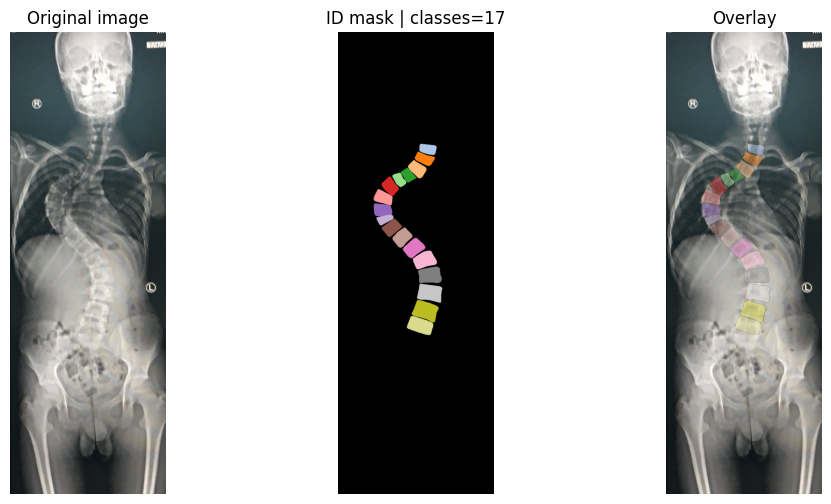

N_47.jpg | source: original | ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


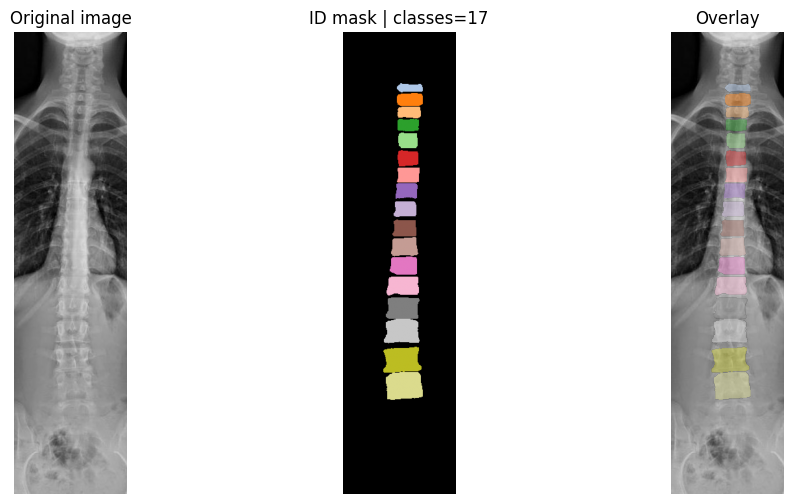

S_139.jpg | source: corrected | ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


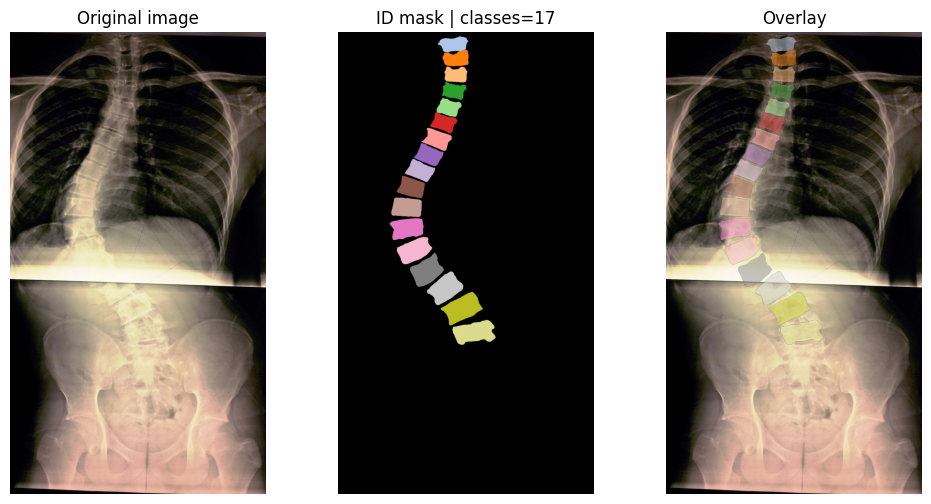

S_194.jpg | source: corrected | ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


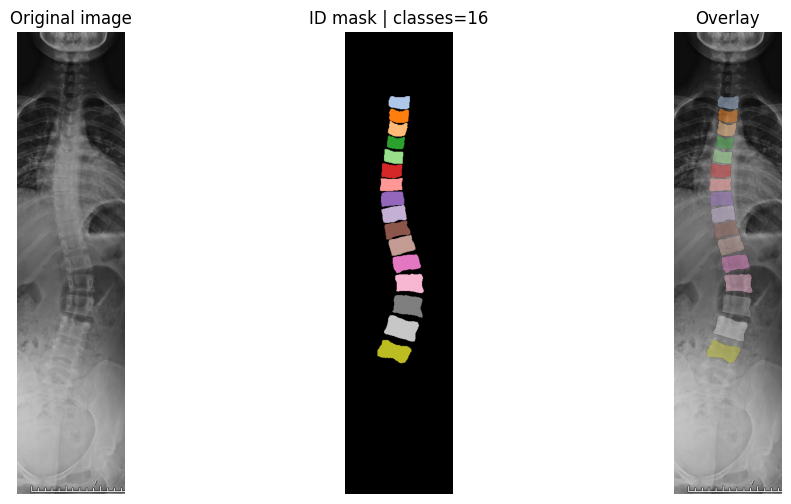

S_133.jpg | source: original | ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


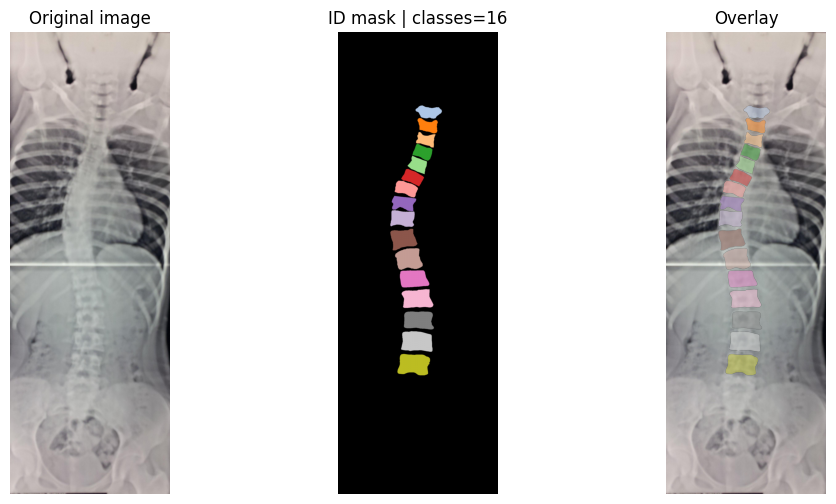

In [10]:
# =========================================================
# Visual sanity check
# =========================================================

def make_mask_cmap():
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    colors[0] = [0, 0, 0, 1]
    return ListedColormap(colors[:CONFIG["num_classes"]])

MASK_CMAP = make_mask_cmap()

def show_image_mask(row, alpha=0.45):
    img = load_image_rgb(row["image_path"])
    mask = load_mask_id(row["mask_path"])

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap=MASK_CMAP, vmin=0, vmax=17)
    plt.title(f"ID mask | classes={row['num_foreground_classes']}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(np.ma.masked_where(mask == 0, mask), cmap=MASK_CMAP, vmin=0, vmax=17, alpha=alpha)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

for _, row in clean_manifest.sample(min(5, len(clean_manifest)), random_state=CONFIG["seed"]).iterrows():
    print(row["imagen"], "| source:", row["mask_source"], "| ids:", row["unique_ids"])
    show_image_mask(row)

In [11]:
# =========================================================
# Create 5-fold cross-validation split
# =========================================================

fold_df = clean_manifest.copy()

# Stratification target:
# combine group + completeness so folds have a similar distribution.
fold_df["stratify_label"] = (
    fold_df["grupo"].astype(str)
    + "_complete_"
    + fold_df["is_complete_17"].astype(str)
)

# If there is a patient column, use it as group. Otherwise use image name as fallback.
possible_group_cols = ["id_paciente", "patient_id", "paciente", "patient"]
group_col = None
for c in possible_group_cols:
    if c in df_index.columns:
        group_col = c
        break

if group_col is not None and group_col in fold_df.columns:
    groups = fold_df[group_col].astype(str).values
    use_group_kfold = len(np.unique(groups)) >= CONFIG["n_folds"]
else:
    groups = None
    use_group_kfold = False

fold_df["fold"] = -1

if use_group_kfold:
    print(f"Using GroupKFold with group column: {group_col}")
    splitter = GroupKFold(n_splits=CONFIG["n_folds"])
    for fold, (_, val_idx) in enumerate(splitter.split(fold_df, groups=groups)):
        fold_df.loc[val_idx, "fold"] = fold
else:
    print("Using StratifiedKFold.")
    splitter = StratifiedKFold(
        n_splits=CONFIG["n_folds"],
        shuffle=True,
        random_state=CONFIG["seed"]
    )

    y = fold_df["stratify_label"].values
    for fold, (_, val_idx) in enumerate(splitter.split(fold_df, y)):
        fold_df.loc[val_idx, "fold"] = fold

assert (fold_df["fold"] >= 0).all(), "Some rows did not receive a fold."

folds_path = META_DIR / "folds_manifest.csv"
fold_df.to_csv(folds_path, index=False)

print("Folds saved to:", folds_path)

display(
    fold_df.groupby(["fold", "grupo", "is_complete_17"])
    .size()
    .rename("count")
    .reset_index()
)

display(fold_df["fold"].value_counts().sort_index().to_frame("count"))

Using StratifiedKFold.
Folds saved to: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/meta/folds_manifest.csv


,fold,grupo,is_complete_17,count
0,0,Normal,False,3
1,0,Normal,True,12
2,0,Scoliosis,False,12
3,0,Scoliosis,True,27
4,1,Normal,False,3
5,1,Normal,True,12
6,1,Scoliosis,False,12
7,1,Scoliosis,True,27
8,2,Normal,False,2
9,2,Normal,True,12


,count
fold,
0,54
1,54
2,53
3,53
4,53


S_34.jpg bbox: (np.int64(62), np.int64(216), np.int64(407), np.int64(1183)) crop: (967, 345, 3) mask: (967, 345)


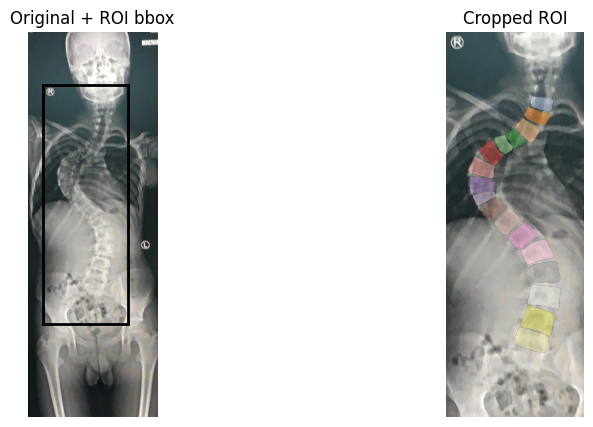

N_47.jpg bbox: (np.int64(47), 0, np.int64(138), np.int64(689)) crop: (689, 91, 3) mask: (689, 91)


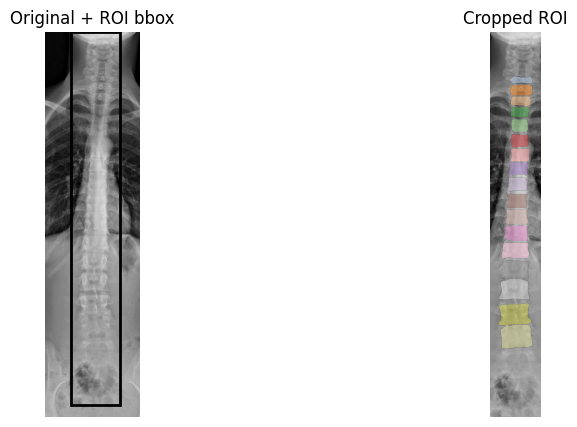

S_139.jpg bbox: (np.int64(134), 0, np.int64(988), np.int64(2098)) crop: (2098, 854, 3) mask: (2098, 854)


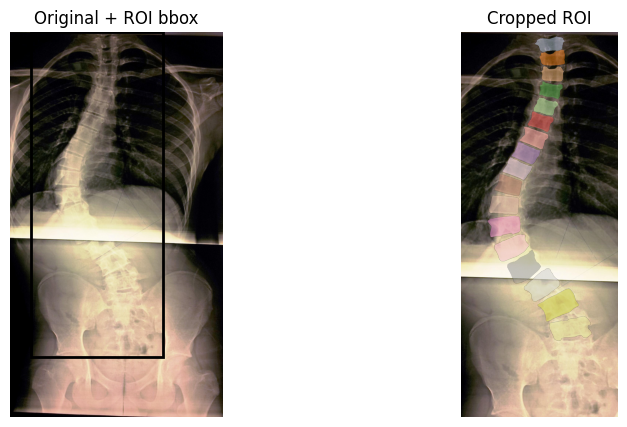

In [12]:
# =========================================================
# ROI crop helpers
# =========================================================

def bbox_from_mask(mask, margin=0.25):
    ys, xs = np.where(mask > 0)

    h, w = mask.shape[:2]

    if len(xs) == 0 or len(ys) == 0:
        return 0, 0, w, h

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    bw = x2 - x1 + 1
    bh = y2 - y1 + 1

    mx = int(bw * margin)
    my = int(bh * margin)

    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(w - 1, x2 + mx)
    y2 = min(h - 1, y2 + my)

    return x1, y1, x2 + 1, y2 + 1

def crop_image_and_mask(image, mask, margin=0.25):
    x1, y1, x2, y2 = bbox_from_mask(mask, margin=margin)
    image_crop = image[y1:y2, x1:x2]
    mask_crop = mask[y1:y2, x1:x2]
    bbox = (x1, y1, x2, y2)
    return image_crop, mask_crop, bbox

# Visual ROI check
for _, row in fold_df.sample(min(3, len(fold_df)), random_state=CONFIG["seed"]).iterrows():
    img = load_image_rgb(row["image_path"])
    mask = load_mask_id(row["mask_path"])
    img_crop, mask_crop, bbox = crop_image_and_mask(img, mask, margin=CONFIG["roi_margin"])

    print(row["imagen"], "bbox:", bbox, "crop:", img_crop.shape, "mask:", mask_crop.shape)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    x1, y1, x2, y2 = bbox
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2))
    plt.title("Original + ROI bbox")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_crop)
    plt.imshow(np.ma.masked_where(mask_crop == 0, mask_crop), cmap=MASK_CMAP, vmin=0, vmax=17, alpha=0.45)
    plt.title("Cropped ROI")
    plt.axis("off")
    plt.show()

In [13]:
# =========================================================
# Augmentations
# =========================================================

IMG_SIZE = CONFIG["image_size"]

train_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE, interpolation=cv2.INTER_LINEAR),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
    ),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.10,
        rotate_limit=7,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
        p=0.7,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.35,
    ),

    A.CLAHE(
        clip_limit=2.0,
        tile_grid_size=(8, 8),
        p=0.20,
    ),

    A.GaussNoise(
        var_limit=(5.0, 25.0),
        p=0.15,
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE, interpolation=cv2.INTER_LINEAR),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

print("Transforms ready.")

Transforms ready.


In [14]:
# =========================================================
# PyTorch Dataset
# =========================================================

class VertebraMulticlassDataset(Dataset):
    def __init__(self, dataframe, transform=None, use_roi=True, roi_margin=0.25):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.use_roi = use_roi
        self.roi_margin = roi_margin

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = load_image_rgb(row["image_path"])
        mask = load_mask_id(row["mask_path"])

        if self.use_roi:
            image, mask, bbox = crop_image_and_mask(
                image,
                mask,
                margin=self.roi_margin,
            )
        else:
            bbox = (0, 0, image.shape[1], image.shape[0])

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"].long()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        meta = {
            "imagen": row["imagen"],
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
            "bbox": bbox,
            "num_foreground_classes": int(row["num_foreground_classes"]),
            "is_complete_17": bool(row["is_complete_17"]),
        }

        return image, mask, meta

def make_loaders(train_df, val_df):
    train_ds = VertebraMulticlassDataset(
        train_df,
        transform=train_transform,
        use_roi=True,
        roi_margin=CONFIG["roi_margin"],
    )

    val_ds = VertebraMulticlassDataset(
        val_df,
        transform=val_transform,
        use_roi=True,
        roi_margin=CONFIG["roi_margin"],
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
        drop_last=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
        drop_last=False,
    )

    return train_loader, val_loader

# Test one batch
tmp_train = fold_df[fold_df["fold"] != 0].reset_index(drop=True)
tmp_val = fold_df[fold_df["fold"] == 0].reset_index(drop=True)

tmp_train_loader, tmp_val_loader = make_loaders(tmp_train, tmp_val)

images, masks, metas = next(iter(tmp_train_loader))

print("Batch images:", images.shape, images.dtype)
print("Batch masks:", masks.shape, masks.dtype)
print("Mask unique IDs in batch:", torch.unique(masks))

Batch images: torch.Size([2, 3, 1024, 1024]) torch.float32
Batch masks: torch.Size([2, 1024, 1024]) torch.int64
Mask unique IDs in batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])


In [15]:
# =========================================================
# Model and losses
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

def build_model():
    model = smp.DeepLabV3Plus(
        encoder_name=CONFIG["encoder_name"],
        encoder_weights=CONFIG["encoder_weights"],
        in_channels=3,
        classes=CONFIG["num_classes"],
        activation=None,
    )
    return model

class CombinedSegmentationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            from_logits=True,
            ignore_index=None,
        )
        self.focal = smp.losses.FocalLoss(
            mode="multiclass",
            ignore_index=None,
        )

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)

        total = (
            0.50 * ce_loss
            + 0.30 * dice_loss
            + 0.20 * focal_loss
        )

        return total, {
            "ce": float(ce_loss.detach().cpu()),
            "dice_loss": float(dice_loss.detach().cpu()),
            "focal": float(focal_loss.detach().cpu()),
            "total": float(total.detach().cpu()),
        }

# Build once to verify with a single image only
torch.cuda.empty_cache()

test_model = build_model().to(DEVICE)
test_model.eval()

with torch.no_grad():
    with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
        test_logits = test_model(images[:1].to(DEVICE))

print("Test logits:", test_logits.shape)

del test_model, test_logits
torch.cuda.empty_cache()

DEVICE: cuda


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

Test logits: torch.Size([1, 18, 1024, 1024])


In [16]:
# =========================================================
# Dice and IoU metrics
# =========================================================

EPS = 1e-7

def compute_batch_class_metrics(preds, targets, num_classes=18):
    """
    preds: [B, H, W] int64
    targets: [B, H, W] int64

    Per-class metric is counted only for images where that class exists in GT.
    This allows valid masks with 16 vertebrae instead of 17.
    """
    preds = preds.detach().cpu()
    targets = targets.detach().cpu()

    stats = {
        c: {
            "intersection": 0.0,
            "pred_area": 0.0,
            "target_area": 0.0,
            "union": 0.0,
            "gt_count": 0,
        }
        for c in range(1, num_classes)
    }

    b = preds.shape[0]

    for i in range(b):
        pred_i = preds[i]
        target_i = targets[i]

        for c in range(1, num_classes):
            target_c = target_i == c

            if target_c.sum().item() == 0:
                continue

            pred_c = pred_i == c

            intersection = (pred_c & target_c).sum().item()
            pred_area = pred_c.sum().item()
            target_area = target_c.sum().item()
            union = (pred_c | target_c).sum().item()

            stats[c]["intersection"] += intersection
            stats[c]["pred_area"] += pred_area
            stats[c]["target_area"] += target_area
            stats[c]["union"] += union
            stats[c]["gt_count"] += 1

    return stats

def merge_metric_stats(total_stats, batch_stats):
    for c, s in batch_stats.items():
        for k, v in s.items():
            total_stats[c][k] += v
    return total_stats

def summarize_class_metrics(stats):
    rows = []

    for c in range(1, CONFIG["num_classes"]):
        s = stats[c]

        if s["gt_count"] == 0:
            dice = np.nan
            iou = np.nan
        else:
            dice = (2 * s["intersection"] + EPS) / (s["pred_area"] + s["target_area"] + EPS)
            iou = (s["intersection"] + EPS) / (s["union"] + EPS)

        rows.append({
            "class_id": c,
            "class_name": CLASS_NAMES[c],
            "dice": dice,
            "iou": iou,
            "gt_count": int(s["gt_count"]),
            "pred_area": s["pred_area"],
            "target_area": s["target_area"],
        })

    metrics_df = pd.DataFrame(rows)

    mean_dice = metrics_df["dice"].mean(skipna=True)
    mean_iou = metrics_df["iou"].mean(skipna=True)

    return metrics_df, mean_dice, mean_iou

def foreground_dice_iou(preds, targets):
    pred_fg = preds > 0
    target_fg = targets > 0

    intersection = (pred_fg & target_fg).sum().item()
    pred_area = pred_fg.sum().item()
    target_area = target_fg.sum().item()
    union = (pred_fg | target_fg).sum().item()

    dice = (2 * intersection + EPS) / (pred_area + target_area + EPS)
    iou = (intersection + EPS) / (union + EPS)

    return dice, iou

In [17]:
# =========================================================
# Post-processing
# =========================================================

def keep_largest_component(binary_mask, min_area=80):
    binary_mask = binary_mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = int(np.argmax(areas)) + 1
    largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

    if largest_area < min_area:
        return np.zeros_like(binary_mask, dtype=np.uint8)

    cleaned = (labels == largest_idx).astype(np.uint8)

    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=1)

    return cleaned

def postprocess_prediction(pred_mask, min_component_area=80):
    """
    pred_mask: [H, W] numpy array with class IDs 0..17.
    Conservative post-processing:
    - keep largest connected component per vertebra class
    - remove tiny artifacts
    - do not relabel anatomy automatically
    """
    pred_mask = pred_mask.astype(np.uint8)
    cleaned = np.zeros_like(pred_mask, dtype=np.uint8)

    for c in range(1, CONFIG["num_classes"]):
        binary = (pred_mask == c).astype(np.uint8)
        cleaned_c = keep_largest_component(binary, min_area=min_component_area)
        cleaned[cleaned_c > 0] = c

    return cleaned

def batch_postprocess(preds):
    preds_np = preds.detach().cpu().numpy()
    processed = []

    for i in range(preds_np.shape[0]):
        p = postprocess_prediction(
            preds_np[i],
            min_component_area=CONFIG["min_component_area"],
        )
        processed.append(p)

    return torch.from_numpy(np.stack(processed)).long()

In [18]:
# =========================================================
# Train and validation functions
# =========================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()

    running_loss = 0.0
    loss_parts_accum = {
        "ce": 0.0,
        "dice_loss": 0.0,
        "focal": 0.0,
        "total": 0.0,
    }

    n_batches = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for images, masks, _ in pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss, loss_parts = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        for k in loss_parts_accum:
            loss_parts_accum[k] += loss_parts[k]

        n_batches += 1

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = running_loss / max(n_batches, 1)
    avg_parts = {k: v / max(n_batches, 1) for k, v in loss_parts_accum.items()}

    return avg_loss, avg_parts

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, use_postprocess=False):
    model.eval()

    running_loss = 0.0
    n_batches = 0

    total_stats = {
        c: {
            "intersection": 0.0,
            "pred_area": 0.0,
            "target_area": 0.0,
            "union": 0.0,
            "gt_count": 0,
        }
        for c in range(1, CONFIG["num_classes"])
    }

    fg_dices = []
    fg_ious = []

    pbar = tqdm(loader, desc="Val", leave=False)

    for images, masks, _ in pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss, _ = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1).detach().cpu()

        if use_postprocess:
            preds = batch_postprocess(preds)

        masks_cpu = masks.detach().cpu()

        batch_stats = compute_batch_class_metrics(
            preds,
            masks_cpu,
            num_classes=CONFIG["num_classes"],
        )
        total_stats = merge_metric_stats(total_stats, batch_stats)

        for i in range(preds.shape[0]):
            fd, fi = foreground_dice_iou(preds[i], masks_cpu[i])
            fg_dices.append(fd)
            fg_ious.append(fi)

        running_loss += loss.item()
        n_batches += 1

    class_metrics_df, mean_dice, mean_iou = summarize_class_metrics(total_stats)

    results = {
        "val_loss": running_loss / max(n_batches, 1),
        "mean_class_dice": mean_dice,
        "mean_class_iou": mean_iou,
        "foreground_dice": float(np.mean(fg_dices)) if len(fg_dices) > 0 else np.nan,
        "foreground_iou": float(np.mean(fg_ious)) if len(fg_ious) > 0 else np.nan,
    }

    return results, class_metrics_df

In [19]:
# =========================================================
# Fold training function
# =========================================================

def train_fold(fold):
    print("=" * 80)
    print(f"Training fold {fold}")
    print("=" * 80)

    fold_output_dir = PROJECT_ROOT / f"fold_{fold}"
    fold_checkpoint_dir = CHECKPOINT_DIR / f"fold_{fold}"
    fold_metrics_dir = METRICS_DIR / f"fold_{fold}"

    final_summary_path = fold_metrics_dir / "final_summary.csv"

    if final_summary_path.exists():
        print(f"Fold {fold} already has final_summary.csv. Skipping to avoid overwriting.")
        return pd.read_csv(final_summary_path).iloc[0].to_dict()

    fold_output_dir.mkdir(parents=True, exist_ok=True)
    fold_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    fold_metrics_dir.mkdir(parents=True, exist_ok=True)

    train_df = fold_df[fold_df["fold"] != fold].reset_index(drop=True)
    val_df = fold_df[fold_df["fold"] == fold].reset_index(drop=True)

    print("Train rows:", len(train_df))
    print("Val rows:", len(val_df))
    print("Train foreground class counts:")
    display(train_df["num_foreground_classes"].value_counts().sort_index().to_frame("count"))
    print("Val foreground class counts:")
    display(val_df["num_foreground_classes"].value_counts().sort_index().to_frame("count"))

    train_loader, val_loader = make_loaders(train_df, val_df)

    model = build_model().to(DEVICE)
    criterion = CombinedSegmentationLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer,
      mode="max",
      factor=0.5,
      patience=10,
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    best_score = -1
    best_epoch = -1
    patience_counter = 0

    history = []

    best_model_path = fold_checkpoint_dir / "best_model.pth"
    last_model_path = fold_checkpoint_dir / "last_model.pth"

    for epoch in range(1, CONFIG["epochs"] + 1):
        start_time = time.time()

        train_loss, train_loss_parts = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            scaler,
        )

        val_results_raw, val_class_metrics_raw = validate_one_epoch(
            model,
            val_loader,
            criterion,
            use_postprocess=False,
        )

        score = val_results_raw["mean_class_dice"]
        scheduler.step(score)

        elapsed = time.time() - start_time
        current_lr = optimizer.param_groups[0]["lr"]

        epoch_record = {
            "fold": fold,
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_loss,
            "train_ce": train_loss_parts["ce"],
            "train_dice_loss": train_loss_parts["dice_loss"],
            "train_focal": train_loss_parts["focal"],
            "val_loss": val_results_raw["val_loss"],
            "val_mean_class_dice": val_results_raw["mean_class_dice"],
            "val_mean_class_iou": val_results_raw["mean_class_iou"],
            "val_foreground_dice": val_results_raw["foreground_dice"],
            "val_foreground_iou": val_results_raw["foreground_iou"],
            "elapsed_seconds": elapsed,
        }

        history.append(epoch_record)

        print(
            f"Fold {fold} | Epoch {epoch:03d}/{CONFIG['epochs']} | "
            f"train_loss={train_loss:.4f} | "
            f"val_dice={val_results_raw['mean_class_dice']:.4f} | "
            f"val_iou={val_results_raw['mean_class_iou']:.4f} | "
            f"fg_dice={val_results_raw['foreground_dice']:.4f} | "
            f"lr={current_lr:.2e} | "
            f"time={elapsed:.1f}s"
        )

        history_df = pd.DataFrame(history)
        history_df.to_csv(fold_metrics_dir / "history.csv", index=False)

        val_class_metrics_raw.to_csv(
            fold_metrics_dir / f"class_metrics_epoch_{epoch:03d}_raw.csv",
            index=False,
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            patience_counter = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "config": CONFIG,
                "fold": fold,
                "epoch": epoch,
                "best_score": best_score,
                "class_names": CLASS_NAMES,
            }, best_model_path)

            print(f"  New best model saved: {best_model_path} | score={best_score:.4f}")
        else:
            patience_counter += 1

        torch.save({
            "model_state_dict": model.state_dict(),
            "config": CONFIG,
            "fold": fold,
            "epoch": epoch,
            "score": score,
            "class_names": CLASS_NAMES,
        }, last_model_path)

        if patience_counter >= CONFIG["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best score: {best_score:.4f}")
            break

    # Load best and evaluate raw + postprocessed
    checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

    final_raw, final_class_raw = validate_one_epoch(
        model,
        val_loader,
        criterion,
        use_postprocess=False,
    )

    final_post, final_class_post = validate_one_epoch(
        model,
        val_loader,
        criterion,
        use_postprocess=True,
    )

    final_class_raw.to_csv(fold_metrics_dir / "final_class_metrics_raw.csv", index=False)
    final_class_post.to_csv(fold_metrics_dir / "final_class_metrics_postprocessed.csv", index=False)

    final_summary = {
        "fold": fold,
        "best_epoch": best_epoch,
        "best_score": best_score,

        "raw_mean_class_dice": final_raw["mean_class_dice"],
        "raw_mean_class_iou": final_raw["mean_class_iou"],
        "raw_foreground_dice": final_raw["foreground_dice"],
        "raw_foreground_iou": final_raw["foreground_iou"],

        "post_mean_class_dice": final_post["mean_class_dice"],
        "post_mean_class_iou": final_post["mean_class_iou"],
        "post_foreground_dice": final_post["foreground_dice"],
        "post_foreground_iou": final_post["foreground_iou"],
    }

    pd.DataFrame([final_summary]).to_csv(fold_metrics_dir / "final_summary.csv", index=False)

    print("Final fold summary:")
    print(json.dumps(final_summary, indent=2))

    del model
    torch.cuda.empty_cache()

    return final_summary

In [30]:
# =========================================================
# Run 5-fold training
# =========================================================

all_fold_summaries = []

for fold in CONFIG["run_folds"]:
    summary = train_fold(fold)
    all_fold_summaries.append(summary)

all_fold_summary_df = pd.DataFrame(all_fold_summaries)
all_fold_summary_path = METRICS_DIR / "all_fold_summary.csv"
all_fold_summary_df.to_csv(all_fold_summary_path, index=False)

print("All fold summary saved to:", all_fold_summary_path)
display(all_fold_summary_df)

print("Mean metrics across folds:")
display(all_fold_summary_df.mean(numeric_only=True).to_frame("mean"))

Training fold 0
Fold 0 already has final_summary.csv. Skipping to avoid overwriting.
Training fold 1
Fold 1 already has final_summary.csv. Skipping to avoid overwriting.
Training fold 2
Fold 2 already has final_summary.csv. Skipping to avoid overwriting.
Training fold 3
Fold 3 already has final_summary.csv. Skipping to avoid overwriting.
Training fold 4
Fold 4 already has final_summary.csv. Skipping to avoid overwriting.
All fold summary saved to: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/metrics/all_fold_summary.csv


,fold,best_epoch,best_score,raw_mean_class_dice,raw_mean_class_iou,raw_foreground_dice,raw_foreground_iou,post_mean_class_dice,post_mean_class_iou,post_foreground_dice,post_foreground_iou
0,0.0,90.0,0.736354,0.736354,0.583778,0.896410,0.814067,0.736964,0.584632,0.889979,0.804217
1,1.0,73.0,0.661599,0.661599,0.494759,0.889982,0.803051,0.662023,0.495256,0.877701,0.784094
2,2.0,89.0,0.649479,0.649479,0.481346,0.898049,0.815993,0.645945,0.477594,0.884427,0.794841
3,3.0,60.0,0.678201,0.678201,0.513412,0.894597,0.809942,0.679541,0.514967,0.890978,0.804084
4,4.0,48.0,0.727606,0.727606,0.573272,0.898703,0.816857,0.727200,0.572747,0.895224,0.811214


Mean metrics across folds:


,mean
fold,2.000000
best_epoch,72.000000
best_score,0.690648
raw_mean_class_dice,0.690648
raw_mean_class_iou,0.529314
raw_foreground_dice,0.895548
raw_foreground_iou,0.811982
post_mean_class_dice,0.690335
post_mean_class_iou,0.529039
post_foreground_dice,0.887662


In [31]:
# =========================================================
# Aggregate per-class metrics across folds
# =========================================================

raw_class_dfs = []
post_class_dfs = []

for fold in CONFIG["run_folds"]:
    fold_metrics_dir = METRICS_DIR / f"fold_{fold}"

    raw_path = fold_metrics_dir / "final_class_metrics_raw.csv"
    post_path = fold_metrics_dir / "final_class_metrics_postprocessed.csv"

    if raw_path.exists():
        raw_df = pd.read_csv(raw_path)
        raw_df["fold"] = fold
        raw_class_dfs.append(raw_df)

    if post_path.exists():
        post_df = pd.read_csv(post_path)
        post_df["fold"] = fold
        post_class_dfs.append(post_df)

raw_all = pd.concat(raw_class_dfs, ignore_index=True)
post_all = pd.concat(post_class_dfs, ignore_index=True)

def aggregate_class_metrics(df):
    agg = (
        df.groupby(["class_id", "class_name"])
        .agg(
            dice_mean=("dice", "mean"),
            dice_std=("dice", "std"),
            iou_mean=("iou", "mean"),
            iou_std=("iou", "std"),
            gt_count_total=("gt_count", "sum"),
        )
        .reset_index()
    )
    return agg

raw_agg = aggregate_class_metrics(raw_all)
post_agg = aggregate_class_metrics(post_all)

raw_agg_path = METRICS_DIR / "per_class_metrics_raw_aggregated.csv"
post_agg_path = METRICS_DIR / "per_class_metrics_postprocessed_aggregated.csv"

raw_agg.to_csv(raw_agg_path, index=False)
post_agg.to_csv(post_agg_path, index=False)

print("Raw aggregated per-class metrics:")
display(raw_agg)

print("Postprocessed aggregated per-class metrics:")
display(post_agg)

print("Saved:")
print(raw_agg_path)
print(post_agg_path)

Raw aggregated per-class metrics:


,class_id,class_name,dice_mean,dice_std,iou_mean,iou_std,gt_count_total
0,1,T1,0.733545,0.055363,0.581667,0.070229,256
1,2,T2,0.726493,0.058037,0.573129,0.073036,263
2,3,T3,0.703769,0.055881,0.545249,0.067110,265
3,4,T4,0.683731,0.048500,0.521113,0.056550,267
4,5,T5,0.680528,0.044772,0.517148,0.051215,266
5,6,T6,0.677084,0.038068,0.512815,0.043589,266
6,7,T7,0.687538,0.027254,0.524384,0.031936,266
7,8,T8,0.686585,0.035708,0.523653,0.041634,265
8,9,T9,0.678524,0.036942,0.514403,0.042225,265
9,10,T10,0.675976,0.042677,0.511784,0.048002,265


Postprocessed aggregated per-class metrics:


,class_id,class_name,dice_mean,dice_std,iou_mean,iou_std,gt_count_total
0,1,T1,0.733101,0.054006,0.580992,0.068431,256
1,2,T2,0.728099,0.054200,0.574789,0.068641,263
2,3,T3,0.705379,0.056418,0.547222,0.067972,265
3,4,T4,0.680228,0.048948,0.517098,0.056784,267
4,5,T5,0.682413,0.043361,0.519235,0.049730,266
5,6,T6,0.676091,0.038402,0.511692,0.043709,266
6,7,T7,0.688104,0.029763,0.525143,0.034837,266
7,8,T8,0.686260,0.038422,0.523417,0.044690,265
8,9,T9,0.678974,0.038446,0.514997,0.043893,265
9,10,T10,0.674462,0.044633,0.510164,0.049890,265


Saved:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/metrics/per_class_metrics_raw_aggregated.csv
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/metrics/per_class_metrics_postprocessed_aggregated.csv


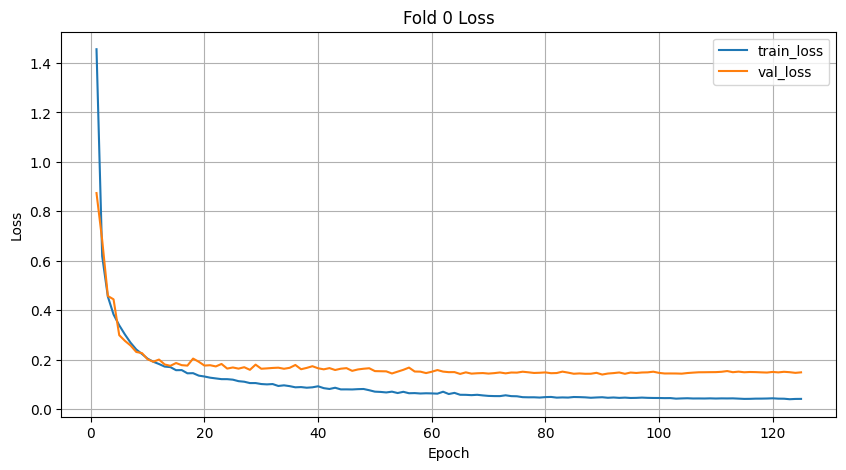

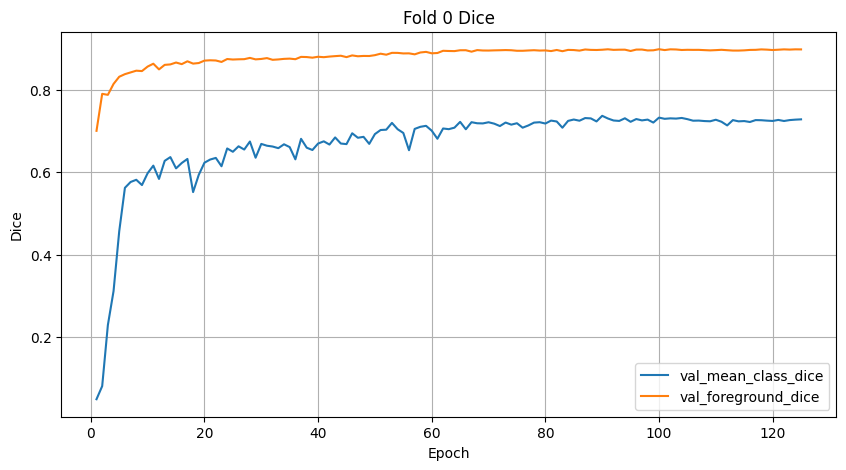

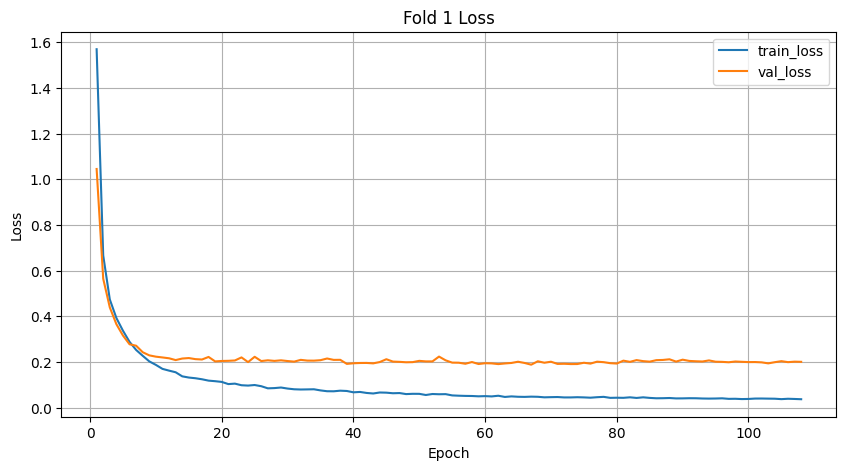

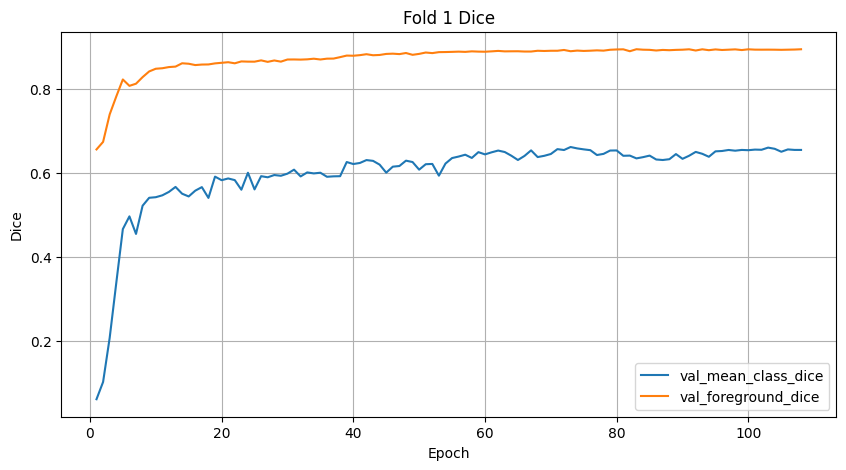

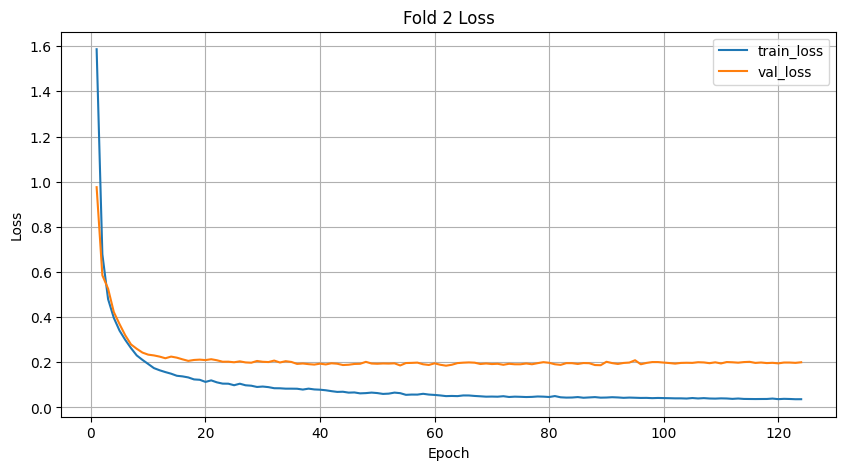

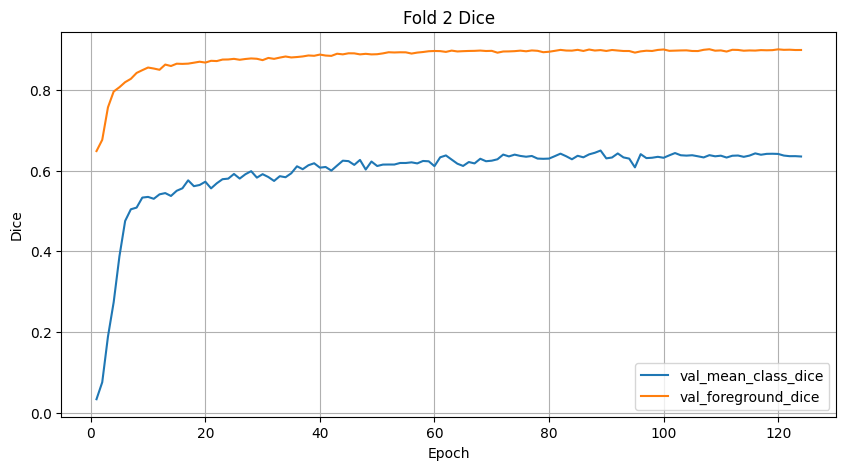

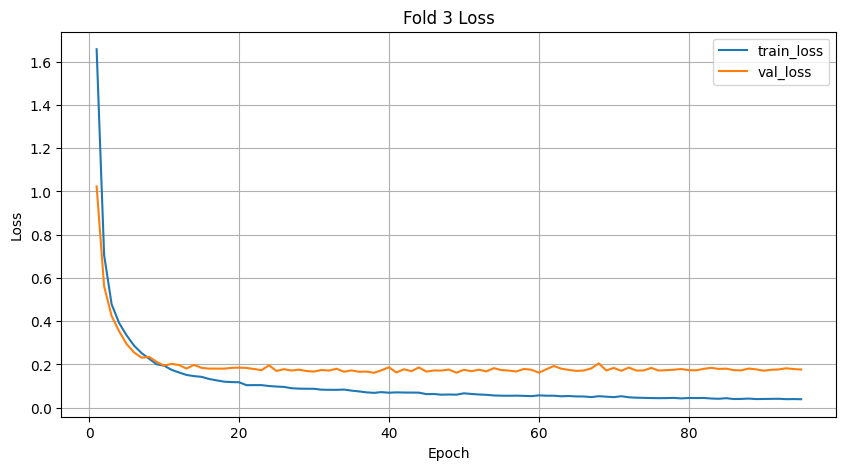

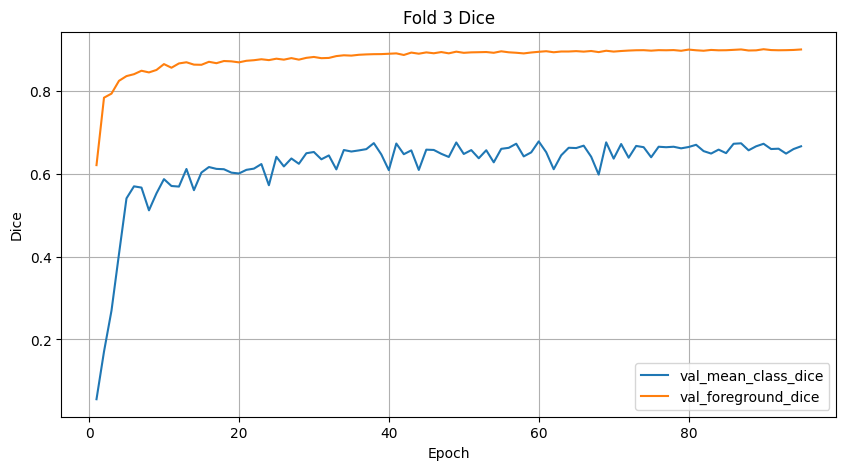

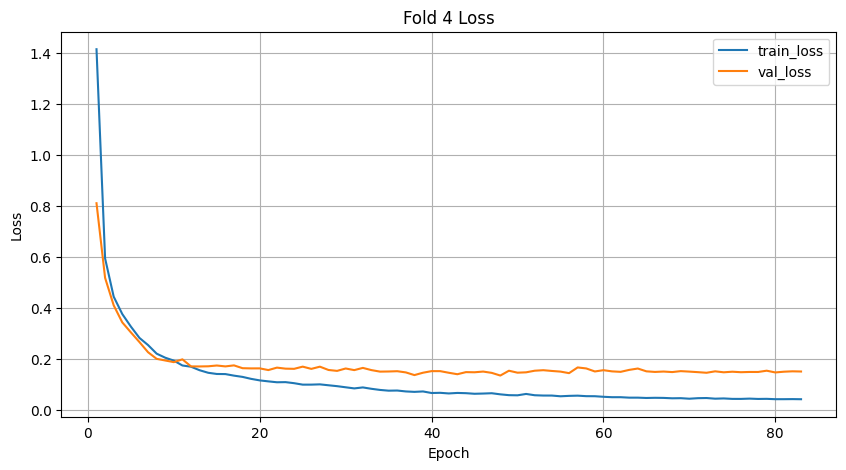

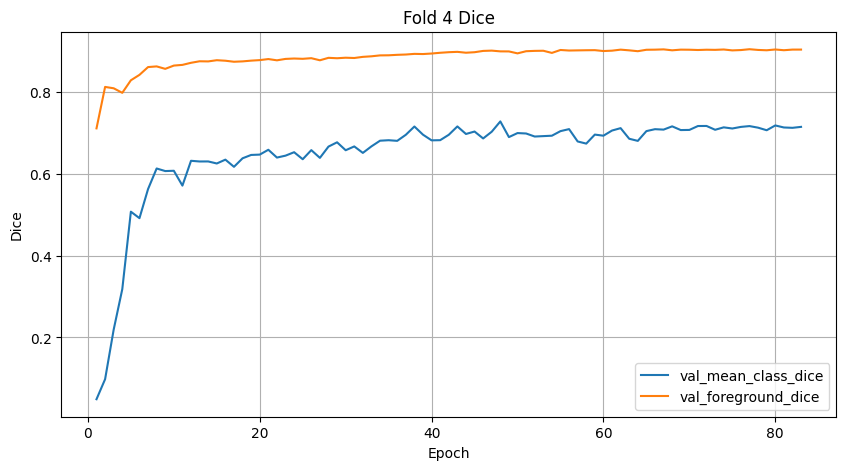

In [32]:
# =========================================================
# Plot training curves
# =========================================================

for fold in CONFIG["run_folds"]:
    history_path = METRICS_DIR / f"fold_{fold}" / "history.csv"

    if not history_path.exists():
        continue

    hist = pd.read_csv(history_path)

    plt.figure(figsize=(10, 5))
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold} Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(PLOTS_DIR / f"fold_{fold}_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(hist["epoch"], hist["val_mean_class_dice"], label="val_mean_class_dice")
    plt.plot(hist["epoch"], hist["val_foreground_dice"], label="val_foreground_dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title(f"Fold {fold} Dice")
    plt.legend()
    plt.grid(True)
    plt.savefig(PLOTS_DIR / f"fold_{fold}_dice.png", dpi=150, bbox_inches="tight")
    plt.show()

In [33]:
# =========================================================
# Load best fold model for inference examples
# =========================================================

summary_df = pd.read_csv(METRICS_DIR / "all_fold_summary.csv")

best_fold = int(summary_df.sort_values("post_mean_class_dice", ascending=False).iloc[0]["fold"])
best_model_path = CHECKPOINT_DIR / f"fold_{best_fold}" / "best_model.pth"

print("Best fold:", best_fold)
print("Best model path:", best_model_path)

model = build_model().to(DEVICE)
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Best model loaded.")

Best fold: 0
Best model path: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/checkpoints/fold_0/best_model.pth
Best model loaded.


In [39]:
# =========================================================
# Inference helpers
# =========================================================

display_transform = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE, interpolation=cv2.INTER_LINEAR),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
    ),
])

def predict_row(row, model, postprocess=True):
    image = load_image_rgb(row["image_path"])
    gt_mask = load_mask_id(row["mask_path"])

    image_crop, gt_crop, bbox = crop_image_and_mask(
        image,
        gt_mask,
        margin=CONFIG["roi_margin"],
    )

    display_transformed = display_transform(image=image_crop, mask=gt_crop)
    image_model_space_display = display_transformed["image"]

    transformed = val_transform(image=image_crop, mask=gt_crop)
    image_tensor = transformed["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(image_tensor)
            pred = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.uint8)

    if postprocess:
        pred = postprocess_prediction(
            pred,
            min_component_area=CONFIG["min_component_area"],
        )

    # The prediction is in resized/padded model space.
    # For visual notebook checks, compare against transformed GT.
    gt_model_space = transformed["mask"].numpy().astype(np.uint8)

    return {
        "image_original": image,
        "gt_original": gt_mask,
        "image_crop": image_crop,
        "gt_crop": gt_crop,
        "gt_model_space": gt_model_space,
        "pred_model_space": pred,
        "bbox": bbox,
        "image_model_space_display": image_model_space_display,
    }

def dice_for_visual(pred, target):
    rows = []

    for c in range(1, CONFIG["num_classes"]):
        target_c = target == c

        if target_c.sum() == 0:
            continue

        pred_c = pred == c

        inter = np.logical_and(pred_c, target_c).sum()
        pred_area = pred_c.sum()
        target_area = target_c.sum()
        union = np.logical_or(pred_c, target_c).sum()

        dice = (2 * inter + EPS) / (pred_area + target_area + EPS)
        iou = (inter + EPS) / (union + EPS)

        rows.append({
            "class_id": c,
            "class_name": CLASS_NAMES[c],
            "dice": dice,
            "iou": iou,
        })

    return pd.DataFrame(rows)

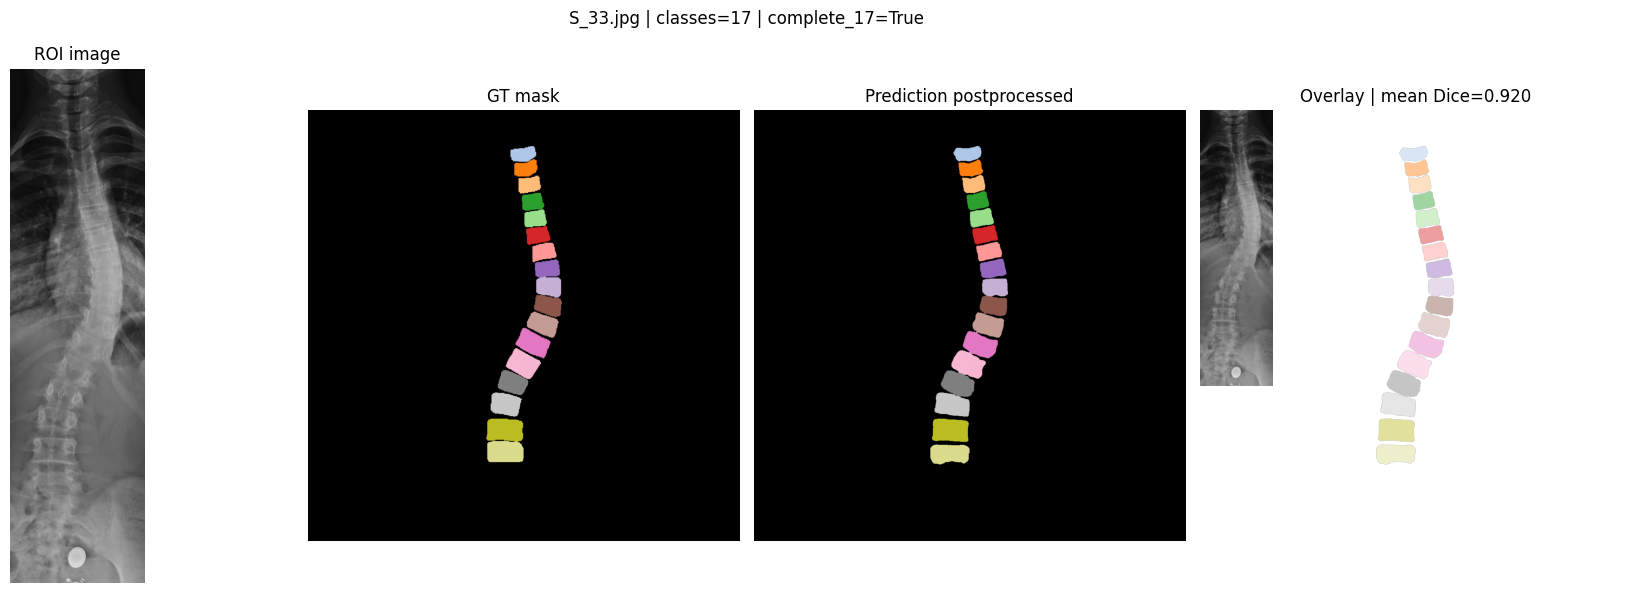

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_00_S_33.png


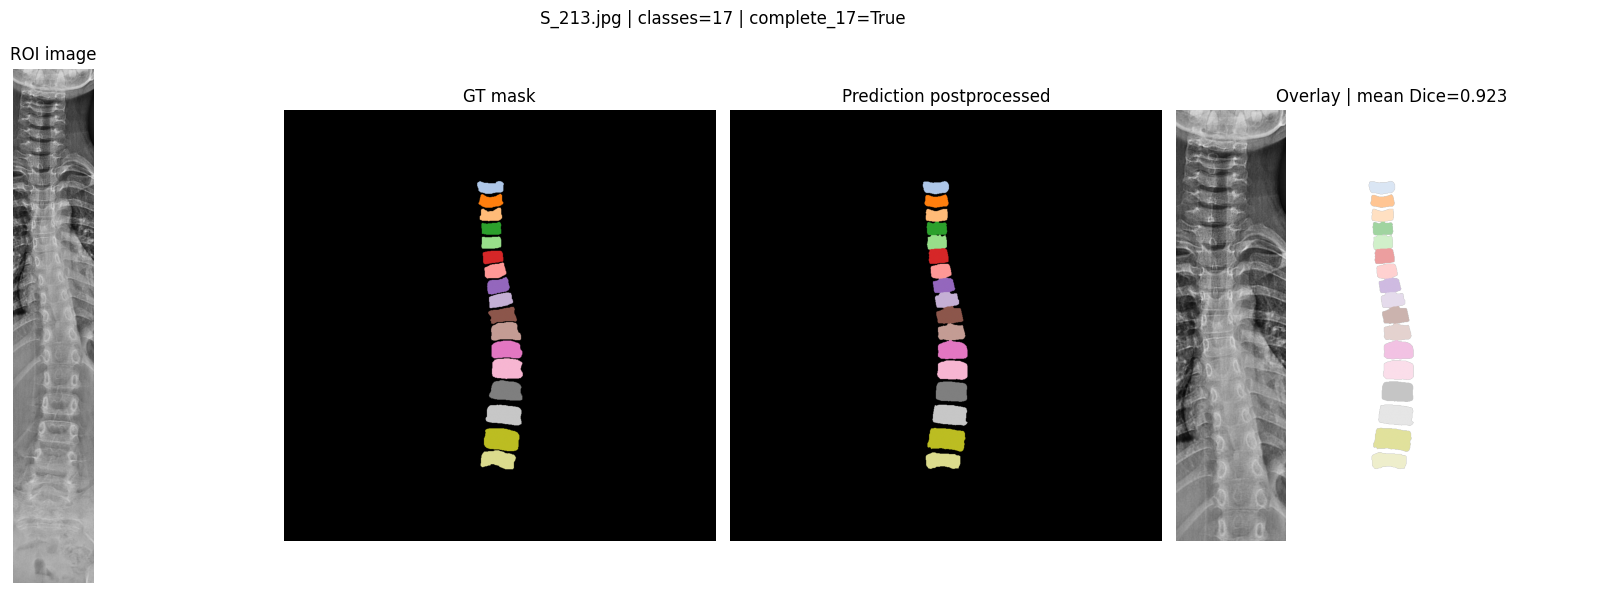

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_01_S_213.png


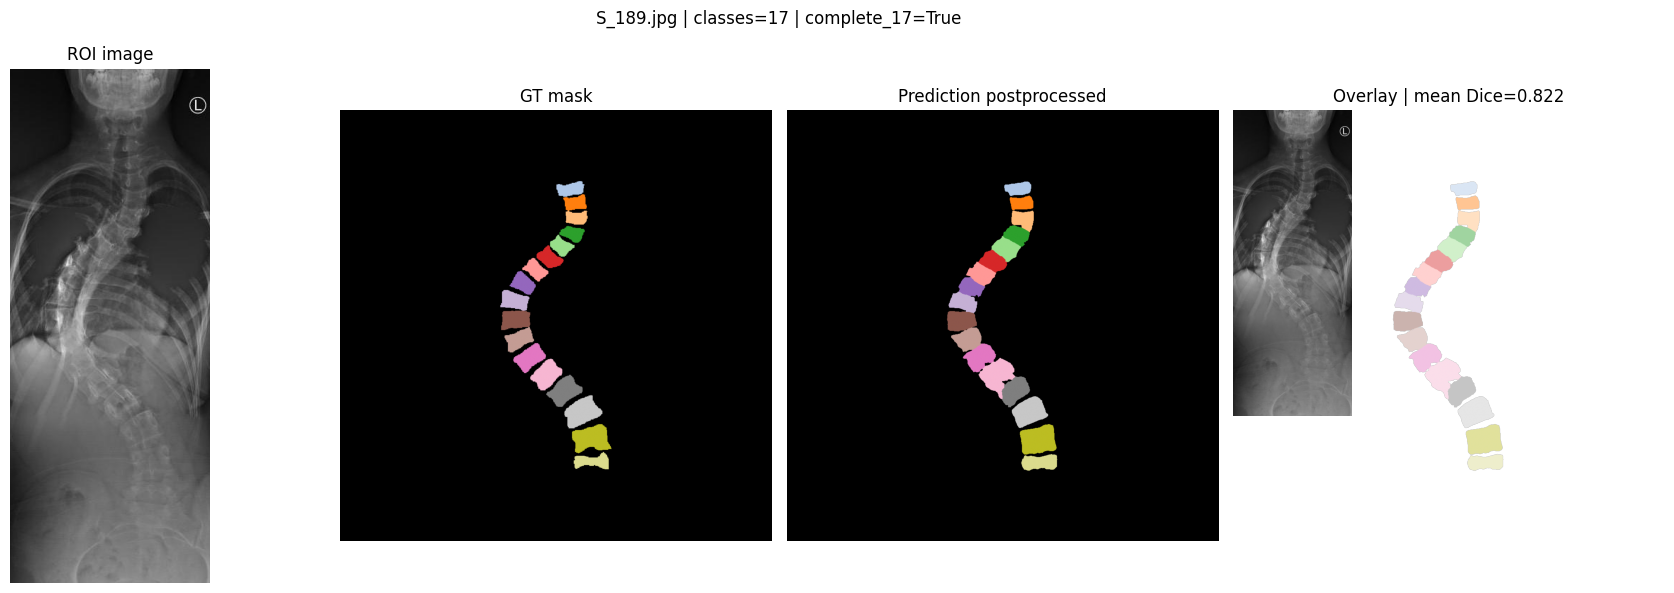

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_02_S_189.png


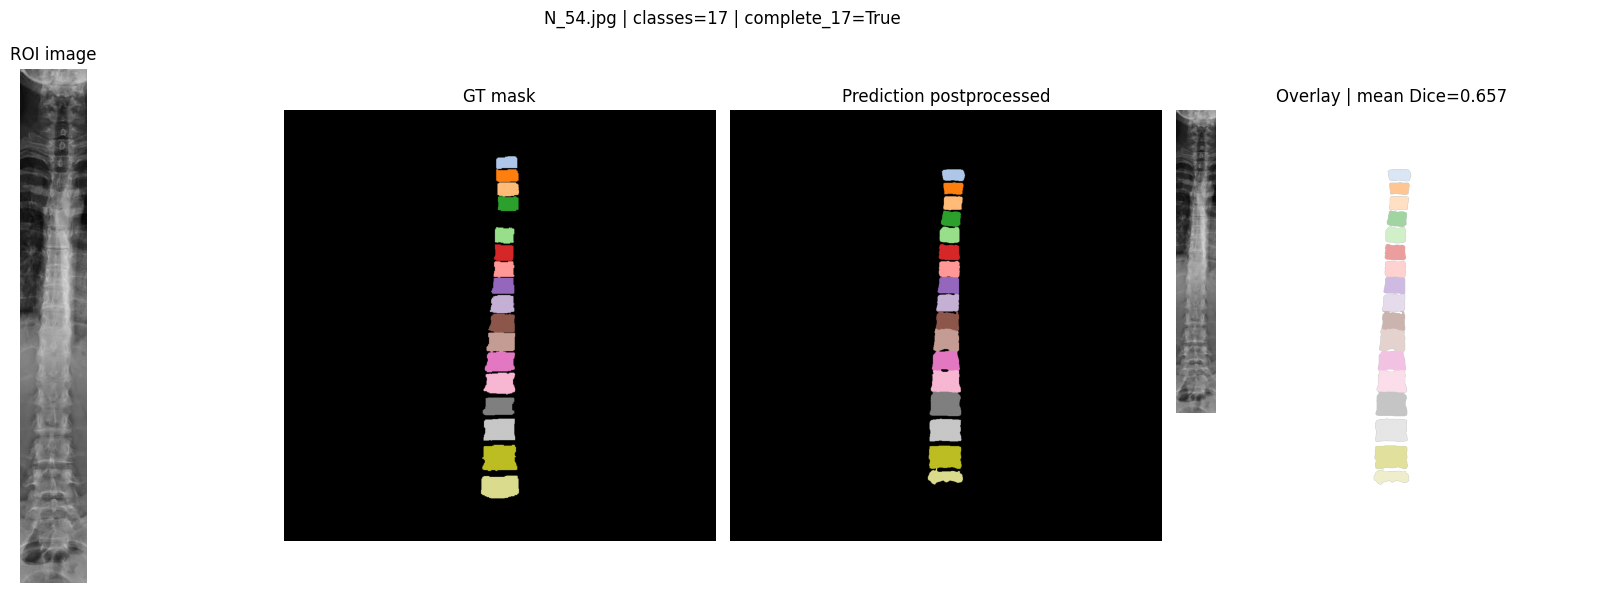

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_03_N_54.png


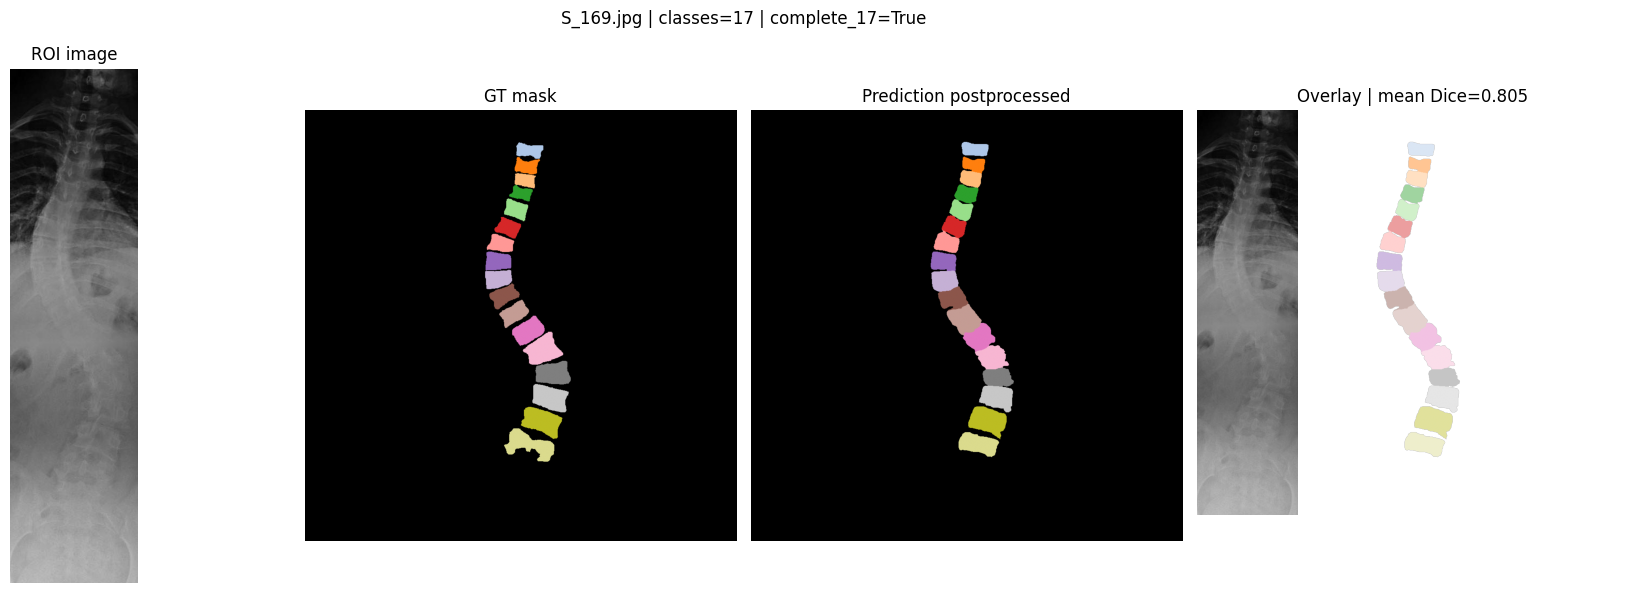

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_04_S_169.png


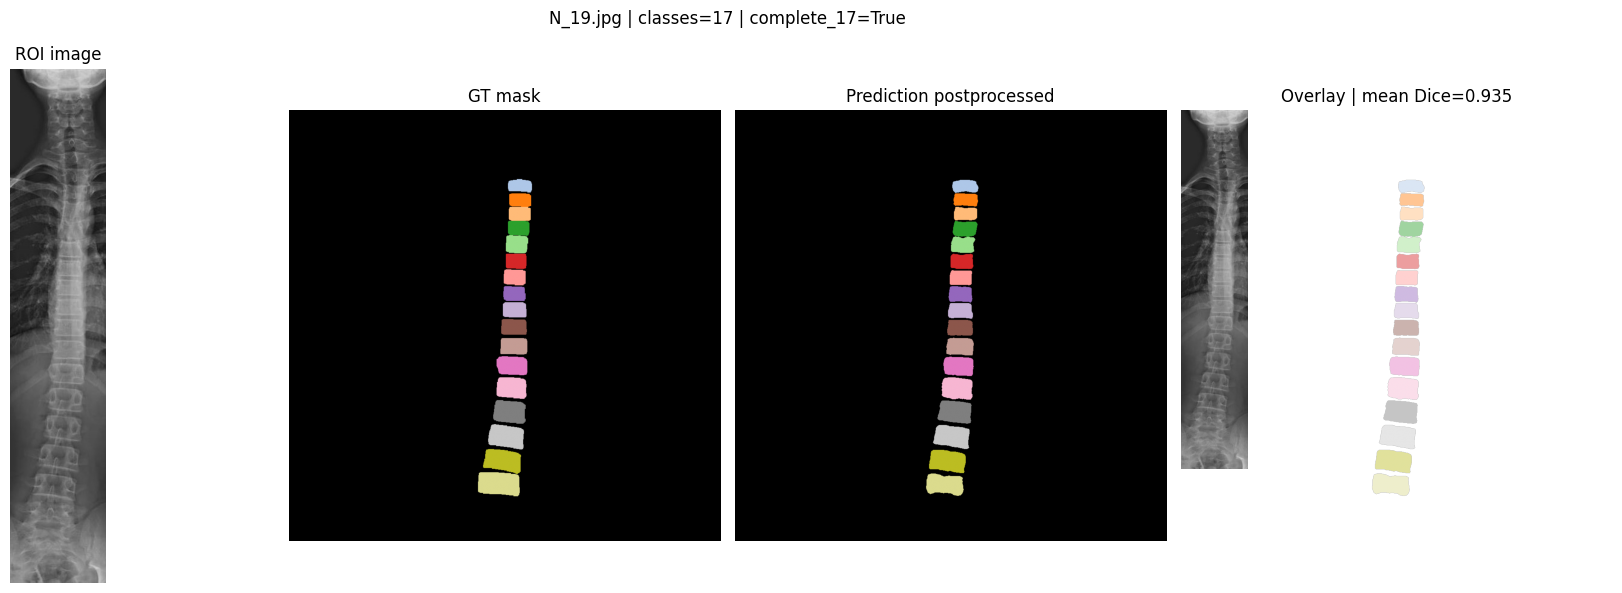

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_05_N_19.png


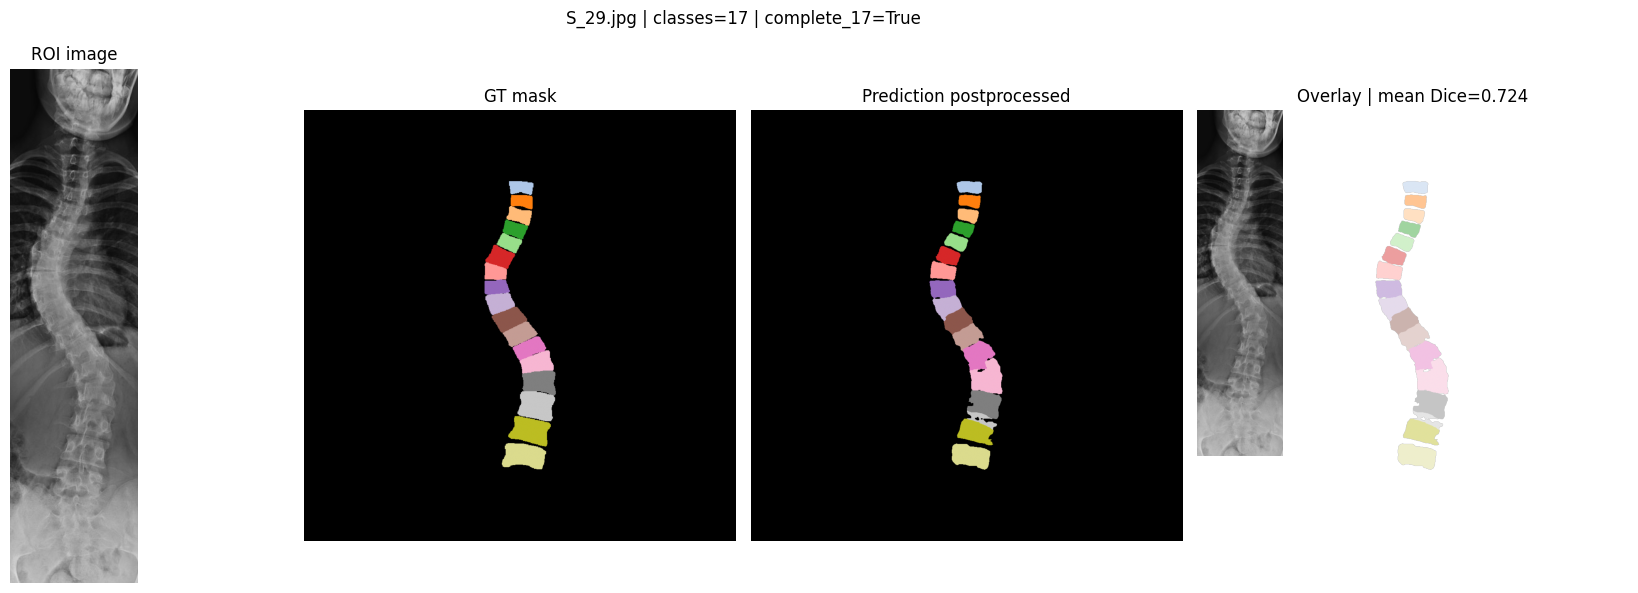

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_06_S_29.png


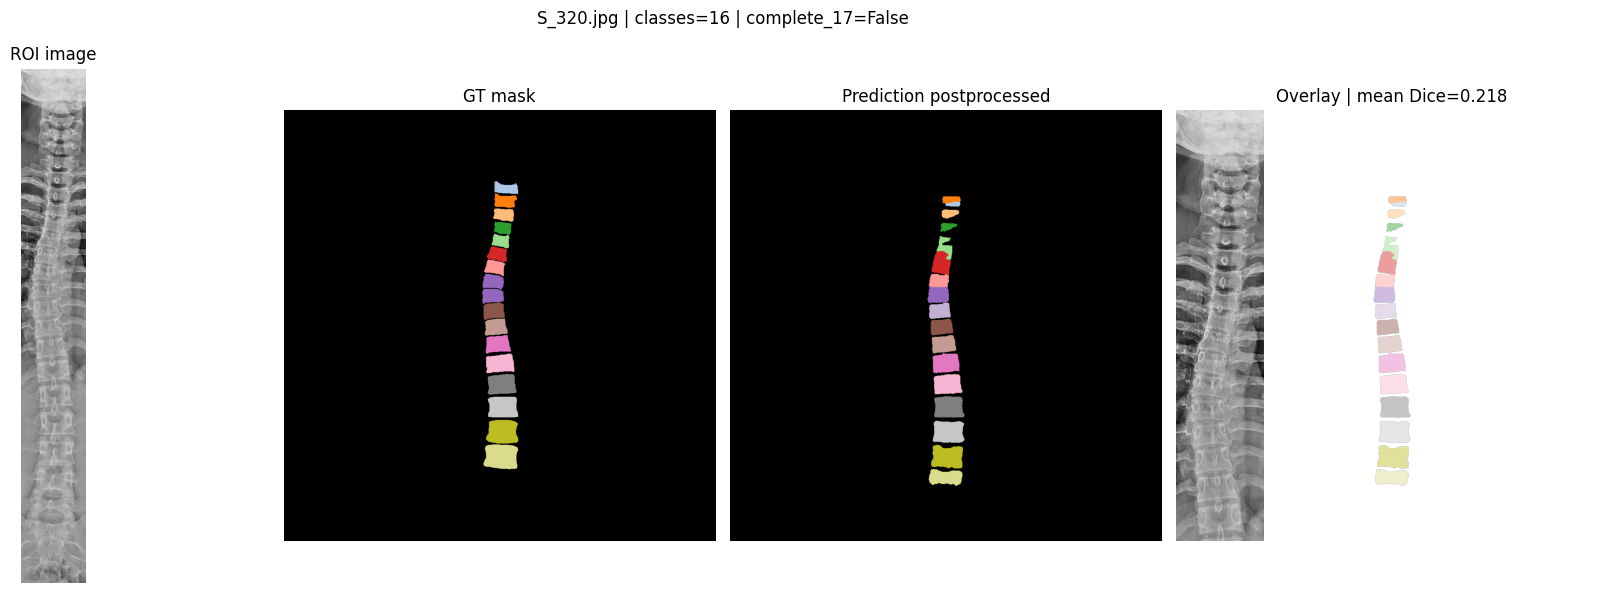

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_07_S_320.png


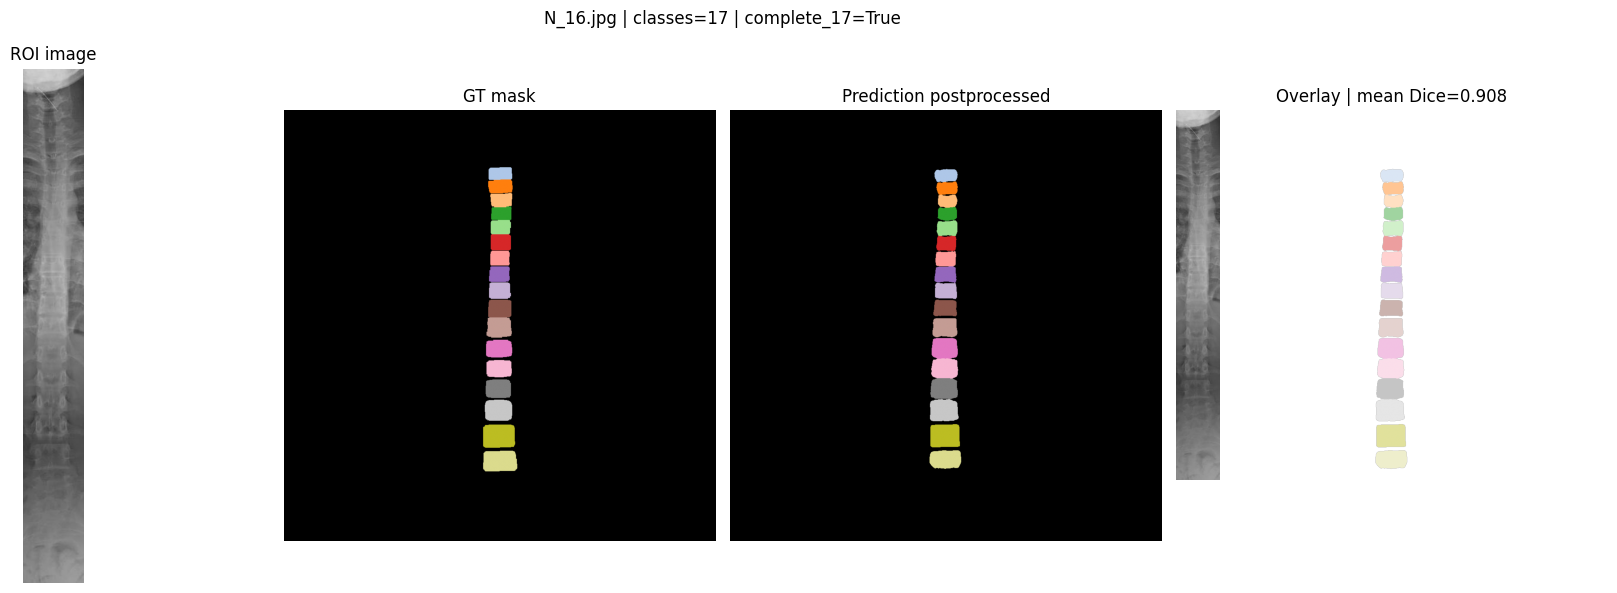

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_08_N_16.png


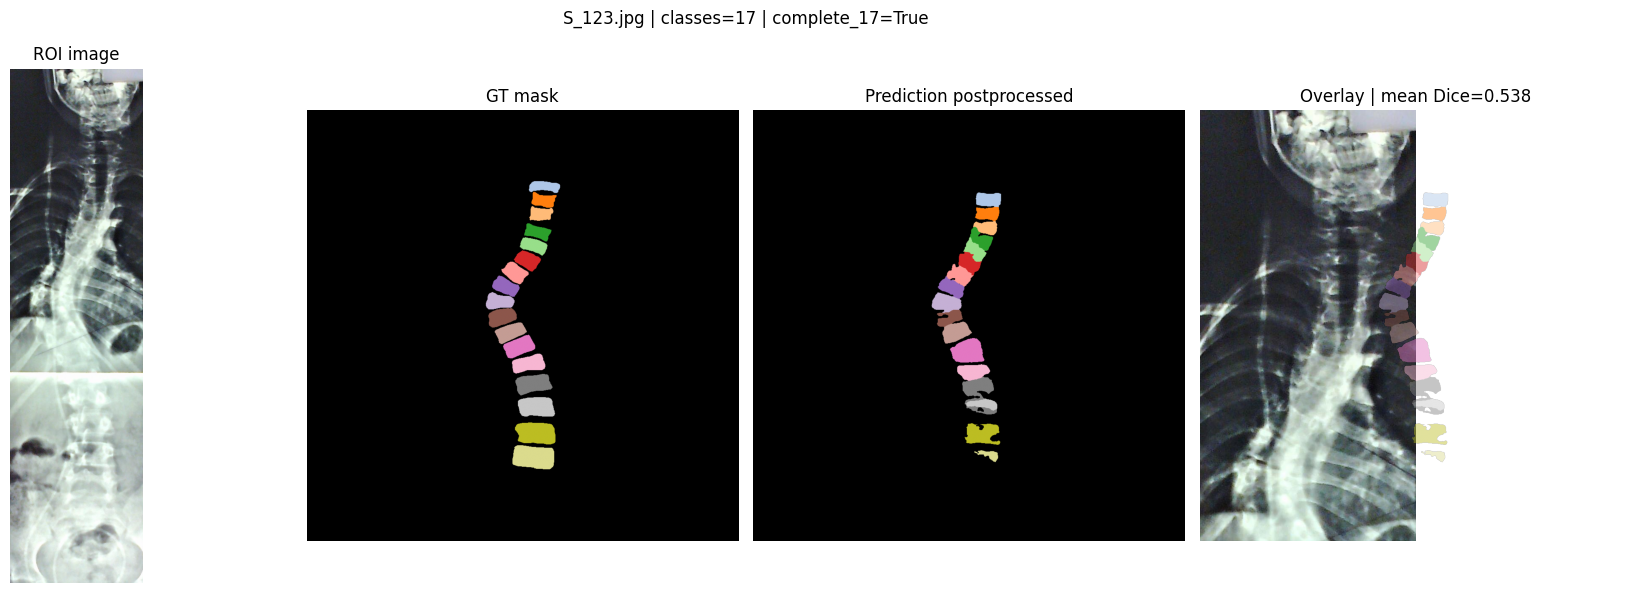

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_09_S_123.png


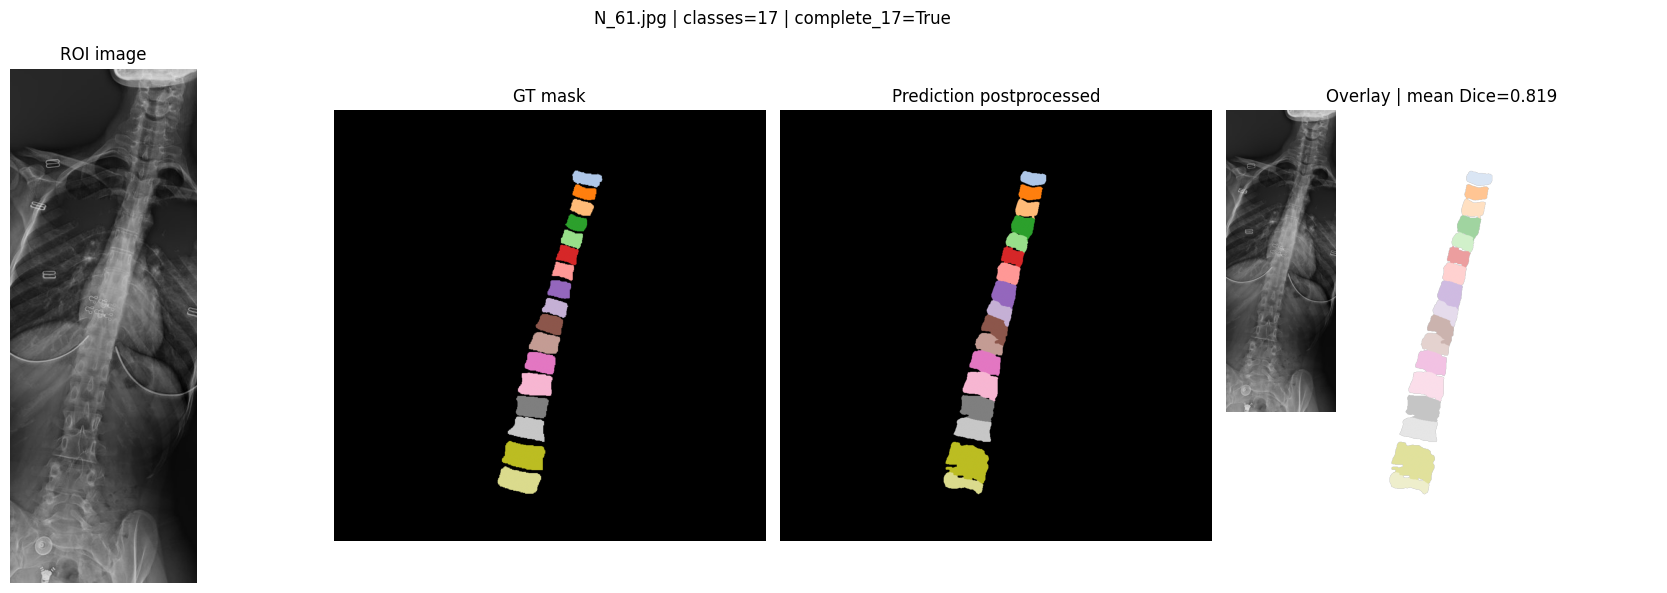

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_10_N_61.png


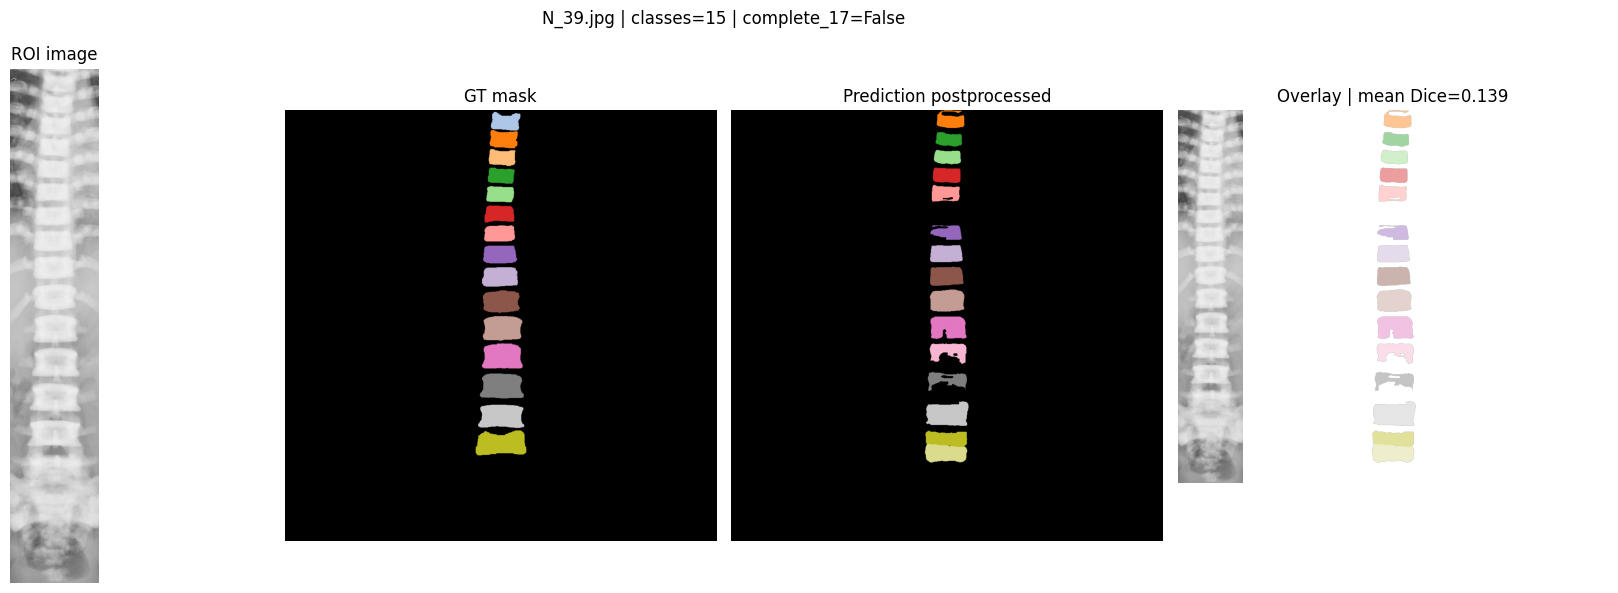

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_11_N_39.png
Example metrics saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_examples/example_metrics.csv


,class_id,class_name,dice_mean,iou_mean
0,1,T1,0.598522,0.544172
1,2,T2,0.651628,0.584186
2,3,T3,0.645007,0.570254
3,4,T4,0.664272,0.572860
4,5,T5,0.734024,0.643533
5,6,T6,0.738595,0.642366
6,7,T7,0.727144,0.653865
7,8,T8,0.792736,0.710229
8,9,T9,0.794424,0.712426
9,10,T10,0.713363,0.628761


In [40]:
# =========================================================
# Save visual inference examples
# =========================================================

example_dir = INFERENCE_DIR / f"best_fold_{best_fold}_examples"
example_dir.mkdir(parents=True, exist_ok=True)

example_df = fold_df[fold_df["fold"] == best_fold].sample(
    min(12, len(fold_df[fold_df["fold"] == best_fold])),
    random_state=CONFIG["seed"],
).reset_index(drop=True)

all_example_metrics = []

for i, row in example_df.iterrows():
    result = predict_row(row, model, postprocess=True)

    img_crop = result["image_crop"]
    gt_model = result["gt_model_space"]
    pred_model = result["pred_model_space"]

    metrics_df = dice_for_visual(pred_model, gt_model)
    metrics_df["imagen"] = row["imagen"]
    all_example_metrics.append(metrics_df)

    mean_dice = metrics_df["dice"].mean() if len(metrics_df) > 0 else np.nan

    fig, axes = plt.subplots(1, 4, figsize=(18, 6))

    axes[0].imshow(img_crop)
    axes[0].set_title("ROI image")
    axes[0].axis("off")

    axes[1].imshow(gt_model, cmap=MASK_CMAP, vmin=0, vmax=17)
    axes[1].set_title("GT mask")
    axes[1].axis("off")

    axes[2].imshow(pred_model, cmap=MASK_CMAP, vmin=0, vmax=17)
    axes[2].set_title("Prediction postprocessed")
    axes[2].axis("off")

    axes[3].imshow(img_crop)
    axes[3].imshow(np.ma.masked_where(pred_model == 0, pred_model), cmap=MASK_CMAP, vmin=0, vmax=17, alpha=0.45)
    axes[3].set_title(f"Overlay | mean Dice={mean_dice:.3f}")
    axes[3].axis("off")

    plt.suptitle(f"{row['imagen']} | classes={row['num_foreground_classes']} | complete_17={row['is_complete_17']}")
    plt.tight_layout()

    save_path = example_dir / f"example_{i:02d}_{Path(str(row['imagen'])).stem}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

if len(all_example_metrics) > 0:
    example_metrics_all = pd.concat(all_example_metrics, ignore_index=True)
    example_metrics_path = example_dir / "example_metrics.csv"
    example_metrics_all.to_csv(example_metrics_path, index=False)
    print("Example metrics saved:", example_metrics_path)
    display(example_metrics_all.groupby(["class_id", "class_name"]).agg(dice_mean=("dice", "mean"), iou_mean=("iou", "mean")).reset_index())

In [41]:
# =========================================================
# Worst-case visual inspection
# =========================================================

def evaluate_examples_for_worst_cases(model, eval_df, max_items=None):
    rows = []

    if max_items is not None:
        eval_df = eval_df.head(max_items)

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating examples"):
        result = predict_row(row, model, postprocess=True)
        pred = result["pred_model_space"]
        gt = result["gt_model_space"]

        metrics_df = dice_for_visual(pred, gt)

        rows.append({
            "imagen": row["imagen"],
            "fold": row["fold"],
            "num_foreground_classes": row["num_foreground_classes"],
            "is_complete_17": row["is_complete_17"],
            "mean_dice": metrics_df["dice"].mean() if len(metrics_df) > 0 else np.nan,
            "mean_iou": metrics_df["iou"].mean() if len(metrics_df) > 0 else np.nan,
        })

    return pd.DataFrame(rows)

best_fold_val_df = fold_df[fold_df["fold"] == best_fold].reset_index(drop=True)
worst_df = evaluate_examples_for_worst_cases(model, best_fold_val_df)

worst_df_path = INFERENCE_DIR / f"best_fold_{best_fold}_worst_cases.csv"
worst_df.to_csv(worst_df_path, index=False)

print("Worst cases saved:", worst_df_path)
display(worst_df.sort_values("mean_dice").head(10))

Evaluating examples:   0%|          | 0/54 [00:00<?, ?it/s]

Worst cases saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases.csv


,imagen,fold,num_foreground_classes,is_complete_17,mean_dice,mean_iou
11,N_51.jpg,0,17,True,0.000288,0.000144
22,S_60.jpg,0,14,False,0.089367,0.057306
47,S_187.jpg,0,17,True,0.116490,0.084876
8,N_39.jpg,0,15,False,0.139100,0.110924
52,S_320.jpg,0,16,False,0.217803,0.157606
9,N_43.jpg,0,16,False,0.409289,0.384641
20,S_40.jpg,0,17,True,0.411038,0.306945
35,S_139.jpg,0,17,True,0.436888,0.370130
30,S_109.jpg,0,17,True,0.452205,0.376783
37,S_150.jpg,0,16,False,0.459776,0.399235


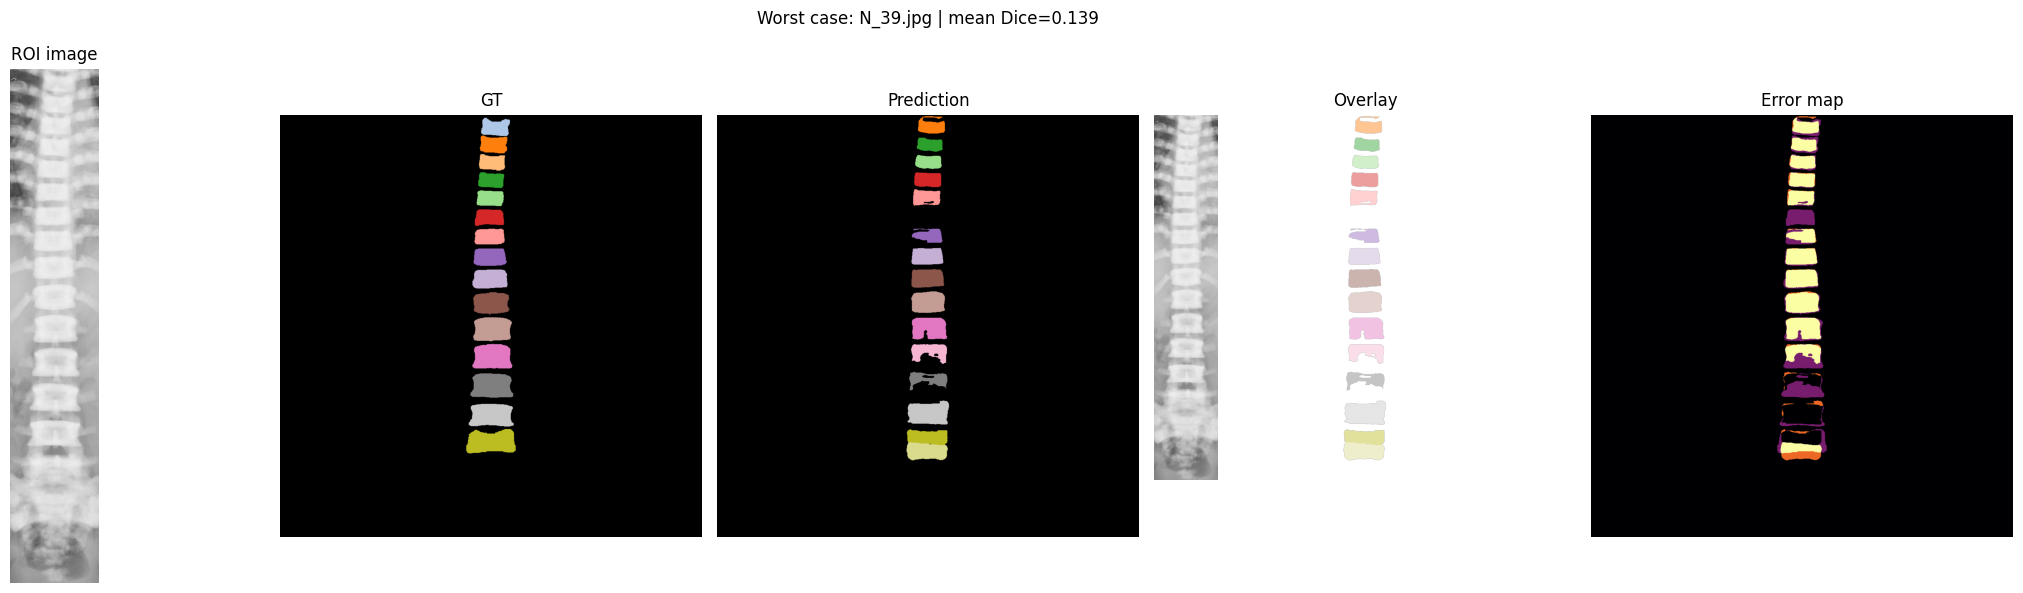

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_00_N_39.png


,class_id,class_name,dice,iou
0,1,T1,4.182350e-11,4.182350e-11
1,2,T2,2.290951e-11,2.290951e-11
2,3,T3,4.766444e-11,4.766444e-11
3,4,T4,2.642008e-11,2.642008e-11
4,5,T5,2.437835e-11,2.437835e-11
5,6,T6,2.166378e-11,2.166378e-11
6,7,T7,2.121341e-11,2.121341e-11
7,8,T8,2.029221e-11,2.029221e-11
8,9,T9,1.556420e-11,1.556420e-11
9,10,T10,1.379120e-11,1.379120e-11


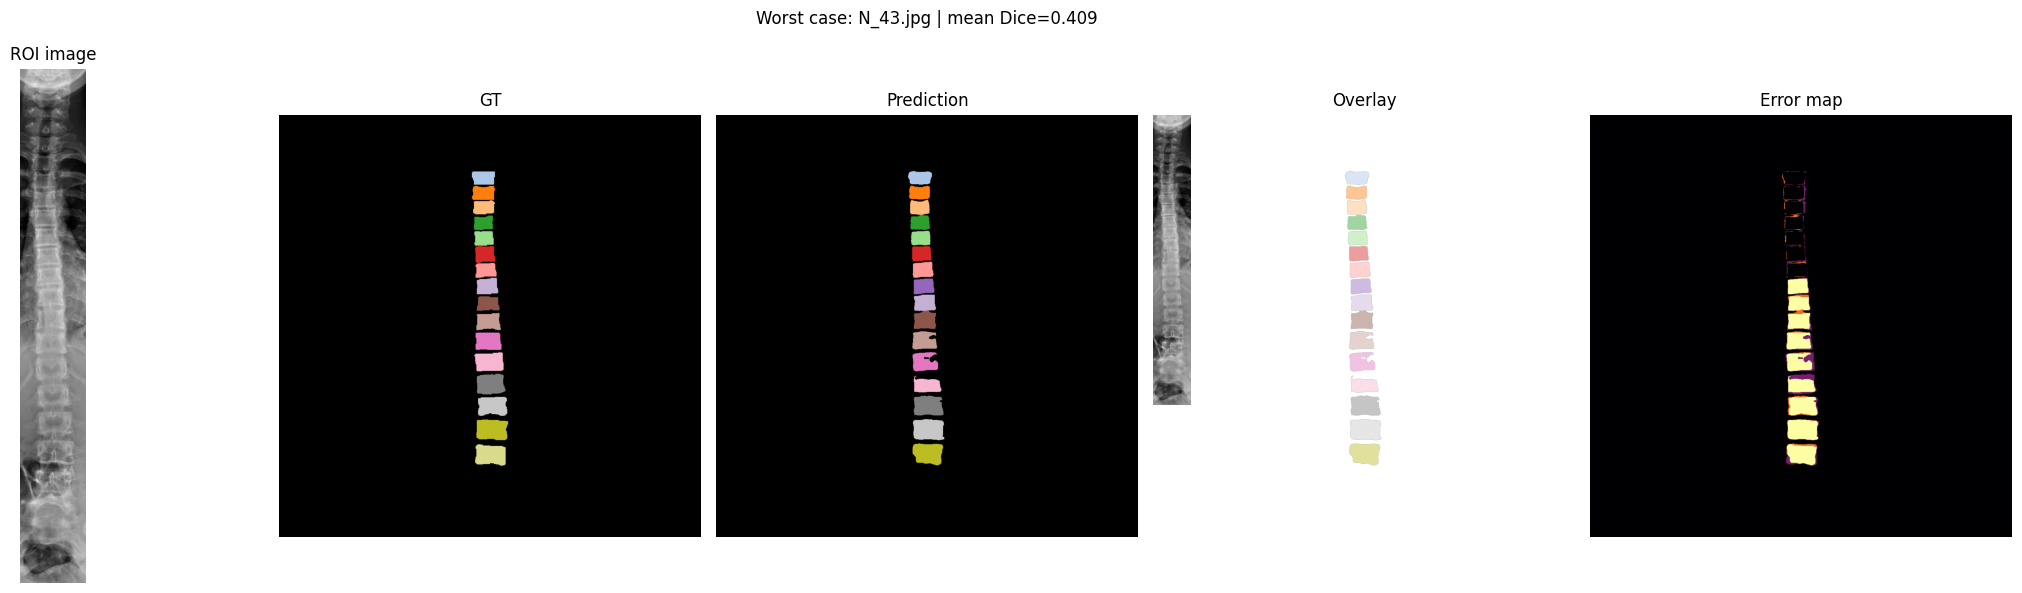

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_01_N_43.png


,class_id,class_name,dice,iou
0,1,T1,9.498489e-01,9.044879e-01
1,2,T2,9.174426e-01,8.474771e-01
2,3,T3,9.175090e-01,8.475904e-01
3,4,T4,9.270620e-01,8.640407e-01
4,5,T5,9.505728e-01,9.058016e-01
5,6,T6,9.349955e-01,8.779264e-01
6,7,T7,9.511973e-01,9.069364e-01
7,9,T9,2.671654e-11,2.671654e-11
8,10,T10,2.648305e-11,2.648305e-11
9,11,T11,2.331002e-11,2.331002e-11


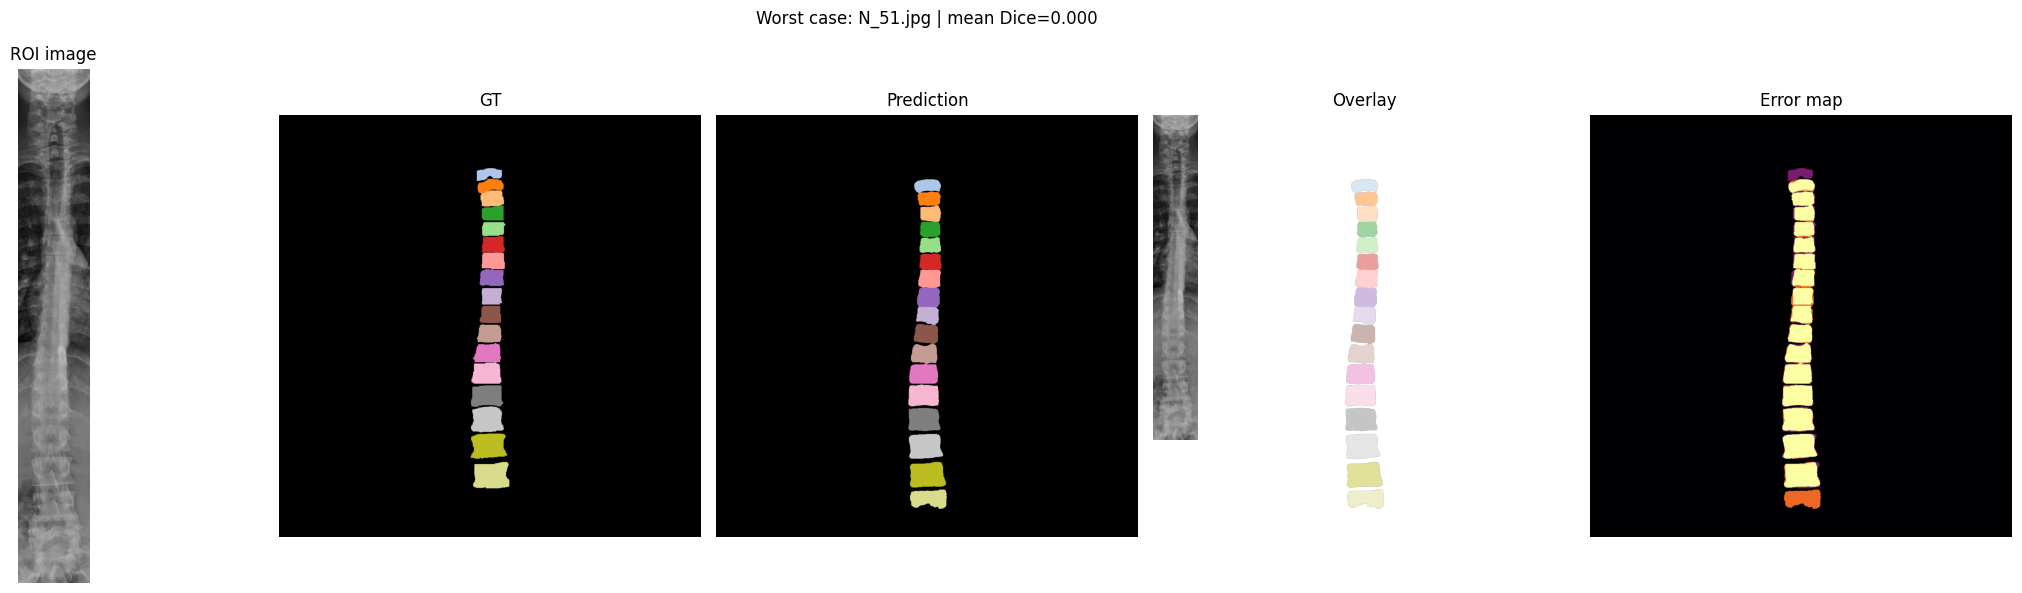

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_02_N_51.png


,class_id,class_name,dice,iou
0,1,T1,3.221649e-11,3.221649e-11
1,2,T2,4.889976e-03,2.450980e-03
2,3,T3,2.767017e-11,2.767017e-11
3,4,T4,2.888504e-11,2.888504e-11
4,5,T5,2.900232e-11,2.900232e-11
5,6,T6,2.553626e-11,2.553626e-11
6,7,T7,2.343018e-11,2.343018e-11
7,8,T8,2.169197e-11,2.169197e-11
8,9,T9,2.569373e-11,2.569373e-11
9,10,T10,2.243662e-11,2.243662e-11


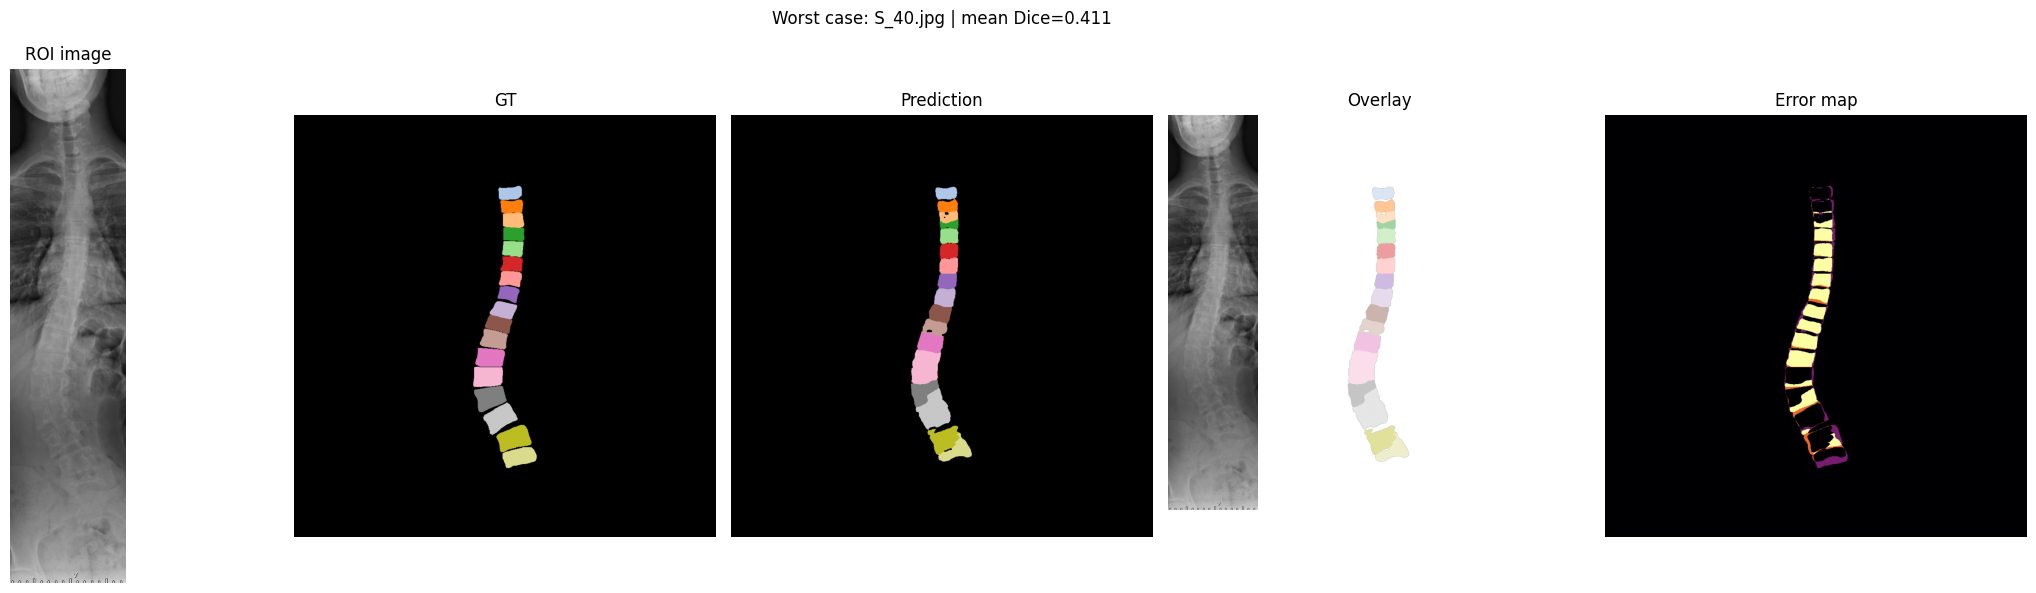

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_03_S_40.png


,class_id,class_name,dice,iou
0,1,T1,0.919081,0.850277
1,2,T2,0.863955,0.760494
2,3,T3,0.645940,0.477039
3,4,T4,0.103171,0.054391
4,5,T5,0.124580,0.066428
5,6,T6,0.107744,0.056940
6,7,T7,0.128091,0.068428
7,8,T8,0.124723,0.066509
8,9,T9,0.186547,0.102868
9,10,T10,0.233889,0.132432


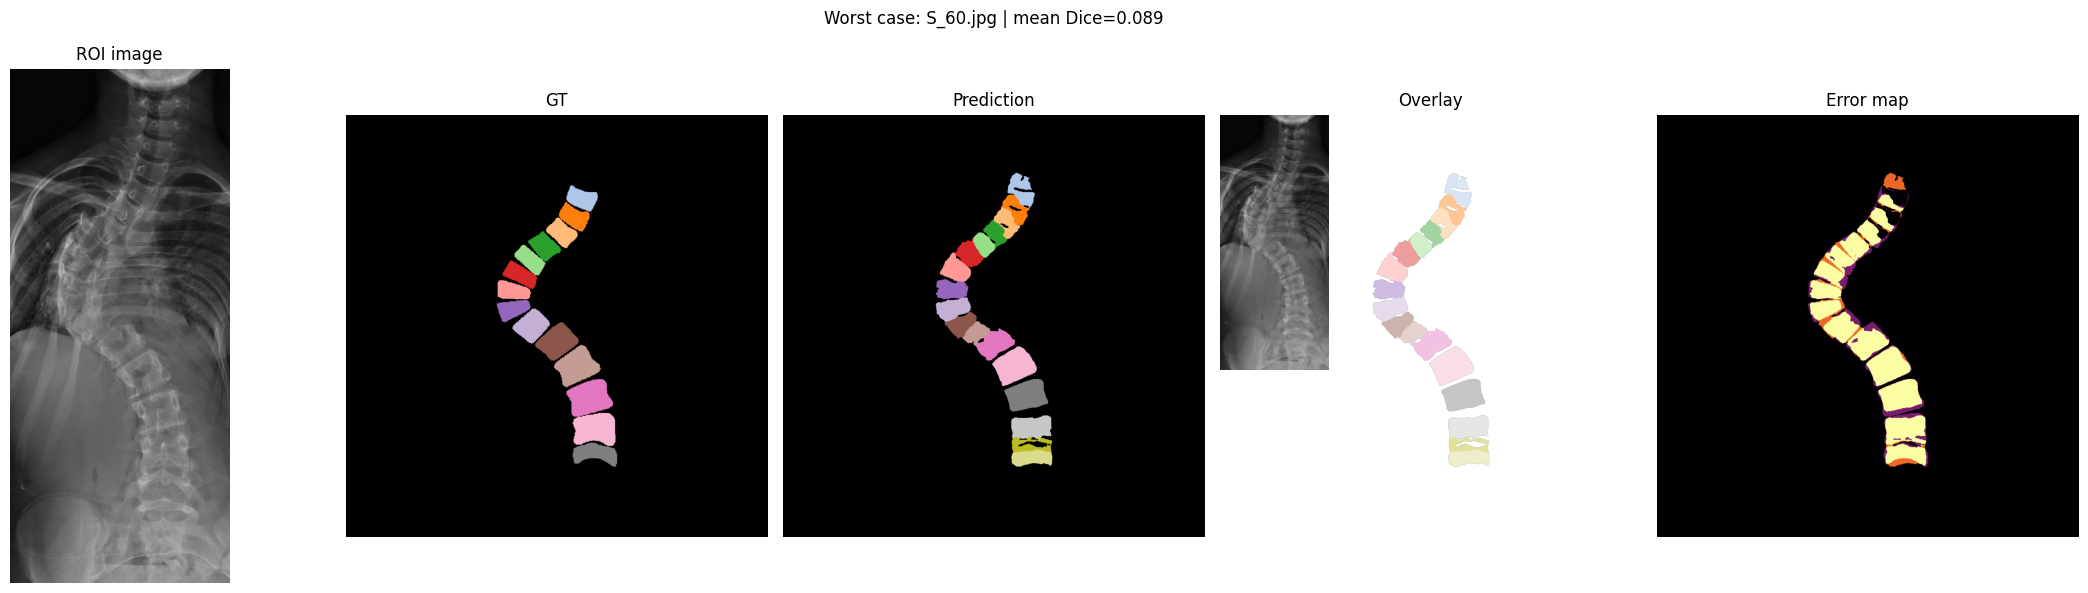

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_04_S_60.png


,class_id,class_name,dice,iou
0,1,T1,5.258354e-01,3.567006e-01
1,2,T2,4.480319e-01,2.886863e-01
2,3,T3,2.520369e-01,1.441889e-01
3,4,T4,6.891271e-03,3.457549e-03
4,5,T5,2.007629e-11,2.007629e-11
5,6,T6,1.700680e-11,1.700680e-11
6,7,T7,1.654260e-11,1.654260e-11
7,8,T8,1.698947e-11,1.698947e-11
8,9,T9,1.834395e-02,9.256878e-03
9,10,T10,1.199616e-11,1.199616e-11


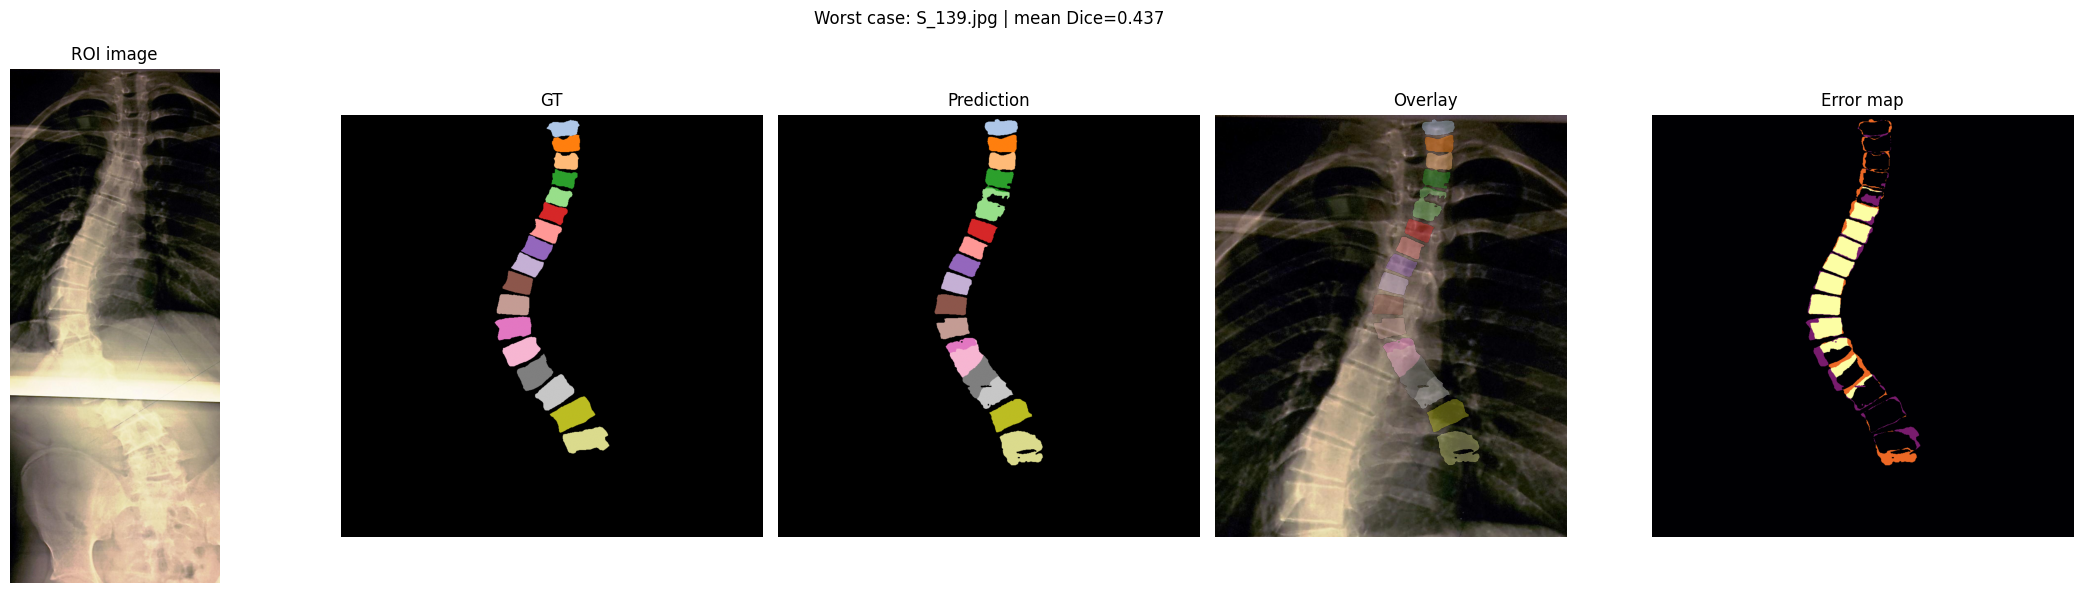

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_05_S_139.png


,class_id,class_name,dice,iou
0,1,T1,8.916358e-01,8.044610e-01
1,2,T2,9.411265e-01,8.887997e-01
2,3,T3,9.095421e-01,8.340918e-01
3,4,T4,8.221226e-01,6.979695e-01
4,5,T5,3.925363e-01,2.441960e-01
5,6,T6,2.038320e-11,2.038320e-11
6,7,T7,1.997603e-11,1.997603e-11
7,8,T8,1.858045e-11,1.858045e-11
8,9,T9,1.805706e-11,1.805706e-11
9,10,T10,1.605652e-11,1.605652e-11


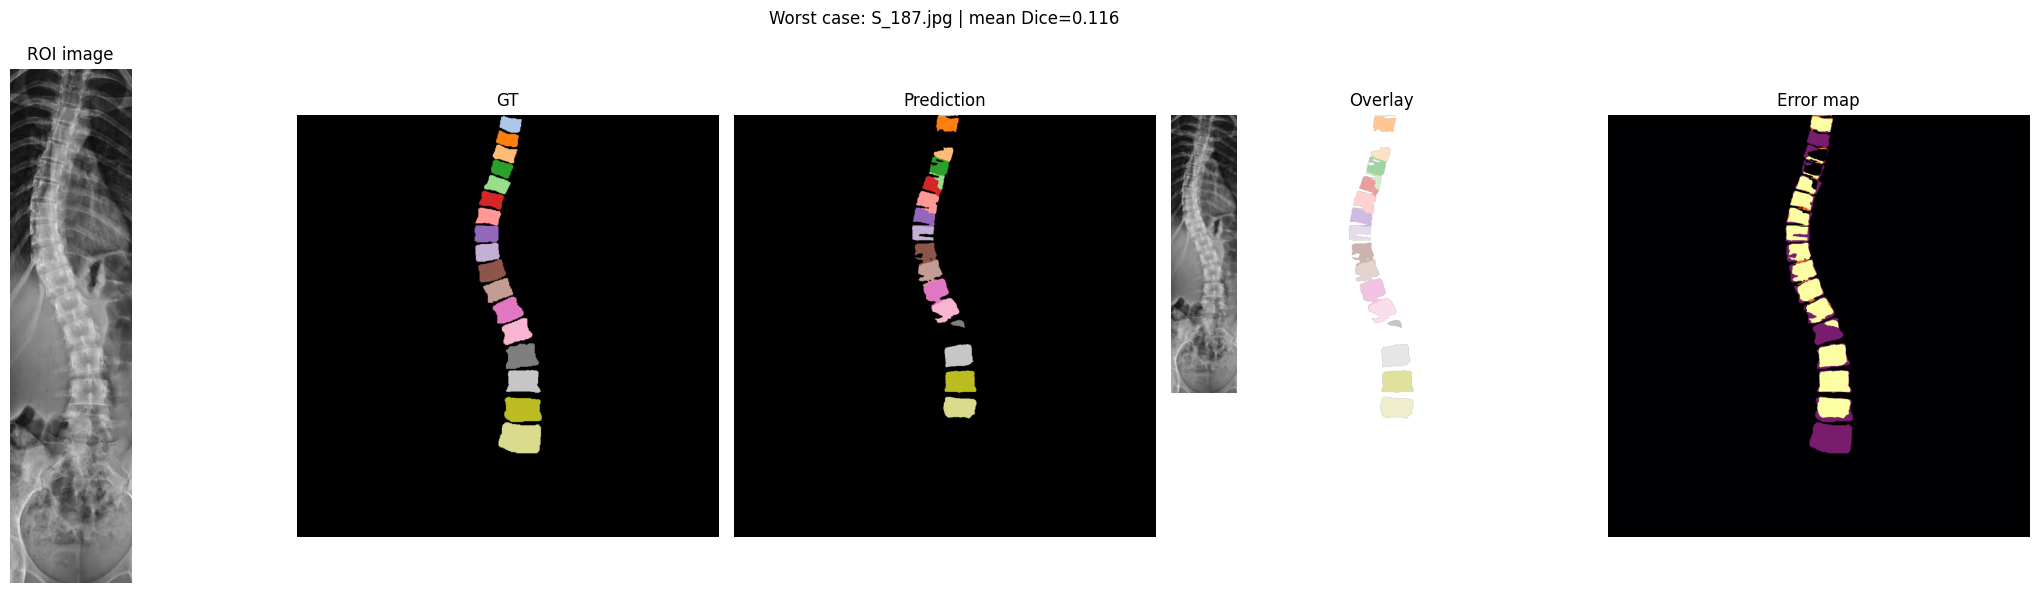

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_06_S_187.png


,class_id,class_name,dice,iou
0,1,T1,4.542873e-03,2.276608e-03
1,2,T2,3.098853e-03,1.551831e-03
2,3,T3,7.072464e-01,5.470852e-01
3,4,T4,7.608069e-01,6.139535e-01
4,5,T5,2.781513e-01,1.615422e-01
5,6,T6,2.167676e-02,1.095714e-02
6,7,T7,9.226038e-02,4.836110e-02
7,8,T8,2.135774e-02,1.079414e-02
8,9,T9,2.585984e-11,2.585984e-11
9,10,T10,2.389588e-02,1.209242e-02


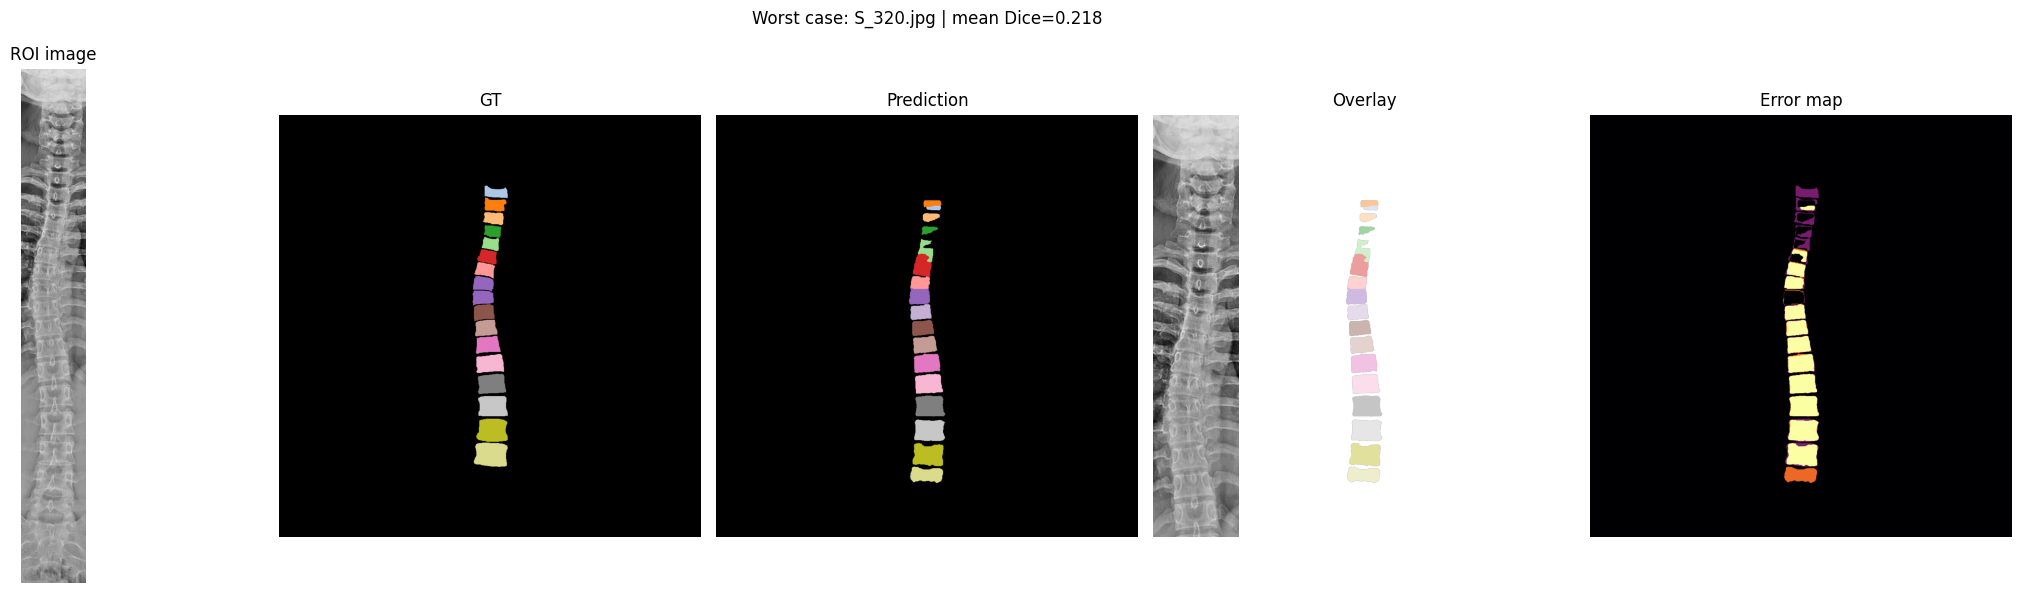

Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/inference/best_fold_0_worst_cases/worst_07_S_320.png


,class_id,class_name,dice,iou
0,1,T1,6.476684e-11,6.476684e-11
1,2,T2,6.180344e-01,4.472141e-01
2,3,T3,6.949767e-01,5.325397e-01
3,4,T4,6.914826e-01,5.284474e-01
4,5,T5,4.184529e-01,2.645846e-01
5,6,T6,3.801550e-01,2.346861e-01
6,7,T7,4.557539e-03,2.283974e-03
7,8,T8,6.771915e-01,5.119347e-01
8,10,T10,2.860412e-11,2.860412e-11
9,11,T11,2.573340e-11,2.573340e-11


In [42]:
# =========================================================
# Visualize worst cases
# =========================================================

worst_vis_dir = INFERENCE_DIR / f"best_fold_{best_fold}_worst_cases"
worst_vis_dir.mkdir(parents=True, exist_ok=True)

worst_names = worst_df.sort_values("mean_dice").head(8)["imagen"].tolist()
worst_rows = best_fold_val_df[best_fold_val_df["imagen"].isin(worst_names)].reset_index(drop=True)

for i, row in worst_rows.iterrows():
    result = predict_row(row, model, postprocess=True)

    img_crop = result["image_crop"]
    gt_model = result["gt_model_space"]
    pred_model = result["pred_model_space"]

    metrics_df = dice_for_visual(pred_model, gt_model)
    mean_dice = metrics_df["dice"].mean() if len(metrics_df) > 0 else np.nan

    error_map = np.zeros_like(gt_model, dtype=np.uint8)
    error_map[(gt_model > 0) & (pred_model == 0)] = 1
    error_map[(gt_model == 0) & (pred_model > 0)] = 2
    error_map[(gt_model > 0) & (pred_model > 0) & (gt_model != pred_model)] = 3

    fig, axes = plt.subplots(1, 5, figsize=(22, 6))

    axes[0].imshow(img_crop)
    axes[0].set_title("ROI image")
    axes[0].axis("off")

    axes[1].imshow(gt_model, cmap=MASK_CMAP, vmin=0, vmax=17)
    axes[1].set_title("GT")
    axes[1].axis("off")

    axes[2].imshow(pred_model, cmap=MASK_CMAP, vmin=0, vmax=17)
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    axes[3].imshow(img_crop)
    axes[3].imshow(np.ma.masked_where(pred_model == 0, pred_model), cmap=MASK_CMAP, vmin=0, vmax=17, alpha=0.45)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    axes[4].imshow(error_map, cmap="inferno", vmin=0, vmax=3)
    axes[4].set_title("Error map")
    axes[4].axis("off")

    plt.suptitle(f"Worst case: {row['imagen']} | mean Dice={mean_dice:.3f}")
    plt.tight_layout()

    save_path = worst_vis_dir / f"worst_{i:02d}_{Path(str(row['imagen'])).stem}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)
    display(metrics_df)

In [43]:
# =========================================================
# Final experiment summary
# =========================================================

print("Project root:", PROJECT_ROOT)
print("Clean manifest:", clean_manifest_path)
print("Folds manifest:", folds_path)
print("Checkpoints:", CHECKPOINT_DIR)
print("Metrics:", METRICS_DIR)
print("Inference examples:", INFERENCE_DIR)
print("Plots:", PLOTS_DIR)

summary_df = pd.read_csv(METRICS_DIR / "all_fold_summary.csv")
display(summary_df)

print("Cross-validation mean:")
display(summary_df.mean(numeric_only=True).to_frame("mean"))

print("Postprocessed per-class metrics:")
display(pd.read_csv(METRICS_DIR / "per_class_metrics_postprocessed_aggregated.csv"))

print("Notebook complete.")

Project root: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold
Clean manifest: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/meta/clean_manifest.csv
Folds manifest: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/meta/folds_manifest.csv
Checkpoints: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/checkpoints
Metrics: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/new_model/vertebrae_multiclass_deeplabv3plus_fivefold/metrics

,fold,best_epoch,best_score,raw_mean_class_dice,raw_mean_class_iou,raw_foreground_dice,raw_foreground_iou,post_mean_class_dice,post_mean_class_iou,post_foreground_dice,post_foreground_iou
0,0.0,90.0,0.736354,0.736354,0.583778,0.896410,0.814067,0.736964,0.584632,0.889979,0.804217
1,1.0,73.0,0.661599,0.661599,0.494759,0.889982,0.803051,0.662023,0.495256,0.877701,0.784094
2,2.0,89.0,0.649479,0.649479,0.481346,0.898049,0.815993,0.645945,0.477594,0.884427,0.794841
3,3.0,60.0,0.678201,0.678201,0.513412,0.894597,0.809942,0.679541,0.514967,0.890978,0.804084
4,4.0,48.0,0.727606,0.727606,0.573272,0.898703,0.816857,0.727200,0.572747,0.895224,0.811214


Cross-validation mean:


,mean
fold,2.000000
best_epoch,72.000000
best_score,0.690648
raw_mean_class_dice,0.690648
raw_mean_class_iou,0.529314
raw_foreground_dice,0.895548
raw_foreground_iou,0.811982
post_mean_class_dice,0.690335
post_mean_class_iou,0.529039
post_foreground_dice,0.887662


Postprocessed per-class metrics:


,class_id,class_name,dice_mean,dice_std,iou_mean,iou_std,gt_count_total
0,1,T1,0.733101,0.054006,0.580992,0.068431,256
1,2,T2,0.728099,0.054200,0.574789,0.068641,263
2,3,T3,0.705379,0.056418,0.547222,0.067972,265
3,4,T4,0.680228,0.048948,0.517098,0.056784,267
4,5,T5,0.682413,0.043361,0.519235,0.049730,266
5,6,T6,0.676091,0.038402,0.511692,0.043709,266
6,7,T7,0.688104,0.029763,0.525143,0.034837,266
7,8,T8,0.686260,0.038422,0.523417,0.044690,265
8,9,T9,0.678974,0.038446,0.514997,0.043893,265
9,10,T10,0.674462,0.044633,0.510164,0.049890,265


Notebook complete.
